# Team 6
# **Explainable Machine Learning for Fetal Health Classification Using Cardiotocography Data**

Jasmine Duong, Lashana Narayan, and Viviana Silva

Department of Engineering, University of San Diego

AAI- 500-02: Introduction to Artificial Intelligence and Machine Learning

Dr. Andrew Van Benschoten

April 2026


In [1]:
%pip install ucimlrepo

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Any, Dict

"""
Load the Cardiotocography dataset from UCI repository.
Reference:
    https://archive.ics.uci.edu/dataset/193/cardiotocography
"""

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

CTG_TARGET_COLS = ["NSP", "CLASS"]
NSP_LABELS = {1: "Normal", 2: "Suspect", 3: "Pathologic"}

# 1.Data Loading
def load_cardiotocography_dataset() -> pd.DataFrame:

    ctg = fetch_ucirepo(id=193)

    if ctg.data is None:
        raise ValueError("Failed to fetch dataset from UCI repository.")

    # Combine features and targets
    df = pd.concat([ctg.data.features, ctg.data.targets], axis=1)

    return df

# 1.1 Exploring dataset
def explore_dataset(df: pd.DataFrame) -> Dict[str, Any]:
    """
    Returns:
        dict: Summary statistics including column types, shape, etc.
    """
    # Identify column types
    cat_cols = [col for col in df.columns if df[col].dtype == 'object']
    num_cols = [col for col in df.columns if df[col].dtype != 'object']

    summary = {
        'shape': df.shape,
        'categorical_columns': cat_cols,
        'numerical_columns': num_cols,
        'total_samples': df.shape[0],
        'total_features': df.shape[1]
    }

    # Display overview
    print("1. DATASET OVERVIEW")
    display(df.head(10))
    print(f"\nColumn Data Types:")
    print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
    print(f"Numerical columns ({len(num_cols)}): {num_cols}")
    print(f"\nDataset Summary:")
    print(f"Total samples: {summary['total_samples']:,}")
    print(f"Total features: {summary['total_features']}")

    return summary
# Load and explore data
df = load_cardiotocography_dataset()
dataset_summary = explore_dataset(df)


1. DATASET OVERVIEW


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,CLASS,NSP
0,120,0.000,0.0,0.000,0.000,0.0,0.000,73,0.5,43,2.4,64,62,126,2,0,120,137,121,73,1,9,2
1,132,0.006,0.0,0.006,0.003,0.0,0.000,17,2.1,0,10.4,130,68,198,6,1,141,136,140,12,0,6,1
2,133,0.003,0.0,0.008,0.003,0.0,0.000,16,2.1,0,13.4,130,68,198,5,1,141,135,138,13,0,6,1
3,134,0.003,0.0,0.008,0.003,0.0,0.000,16,2.4,0,23.0,117,53,170,11,0,137,134,137,13,1,6,1
4,132,0.007,0.0,0.008,0.000,0.0,0.000,16,2.4,0,19.9,117,53,170,9,0,137,136,138,11,1,2,1
5,134,0.001,0.0,0.010,0.009,0.0,0.002,26,5.9,0,0.0,150,50,200,5,3,76,107,107,170,0,8,3
6,134,0.001,0.0,0.013,0.008,0.0,0.003,29,6.3,0,0.0,150,50,200,6,3,71,107,106,215,0,8,3
7,122,0.000,0.0,0.000,0.000,0.0,0.000,83,0.5,6,15.6,68,62,130,0,0,122,122,123,3,1,9,3
8,122,0.000,0.0,0.002,0.000,0.0,0.000,84,0.5,5,13.6,68,62,130,0,0,122,122,123,3,1,9,3
9,122,0.000,0.0,0.003,0.000,0.0,0.000,86,0.3,6,10.6,68,62,130,1,0,122,122,123,1,1,9,3



Column Data Types:
Categorical columns (0): []
Numerical columns (23): ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency', 'CLASS', 'NSP']

Dataset Summary:
Total samples: 2,126
Total features: 23


In [3]:
#get a concise summary of the dataset including data types, non-null counts, and memory usage.
df.info()
#.describe method enable us to detect outliers in the data for further investigation
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2126 non-null   int64  
 1   AC        2126 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2126 non-null   float64
 6   DP        2126 non-null   float64
 7   ASTV      2126 non-null   int64  
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   int64  
 10  MLTV      2126 non-null   float64
 11  Width     2126 non-null   int64  
 12  Min       2126 non-null   int64  
 13  Max       2126 non-null   int64  
 14  Nmax      2126 non-null   int64  
 15  Nzeros    2126 non-null   int64  
 16  Mode      2126 non-null   int64  
 17  Mean      2126 non-null   int64  
 18  Median    2126 non-null   int64  
 19  Variance  2126 non-null   int64  
 20  Tendency  2126 non-null   int6

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,CLASS,NSP
count,2126.00,2126.00,2126.00,2126.00,2126.00,2126.0,2126.0,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00,2126.00
mean,133.30,0.00,0.01,0.00,0.00,0.0,0.0,46.99,1.33,9.85,8.19,70.45,93.58,164.03,4.07,0.32,137.45,134.61,138.09,18.81,0.32,4.51,1.30
std,9.84,0.00,0.05,0.00,0.00,0.0,0.0,17.19,0.88,18.40,5.63,38.96,29.56,17.94,2.95,0.71,16.38,15.59,14.47,28.98,0.61,3.03,0.61
min,106.00,0.00,0.00,0.00,0.00,0.0,0.0,12.00,0.20,0.00,0.00,3.00,50.00,122.00,0.00,0.00,60.00,73.00,77.00,0.00,-1.00,1.00,1.00
25%,126.00,0.00,0.00,0.00,0.00,0.0,0.0,32.00,0.70,0.00,4.60,37.00,67.00,152.00,2.00,0.00,129.00,125.00,129.00,2.00,0.00,2.00,1.00
50%,133.00,0.00,0.00,0.00,0.00,0.0,0.0,49.00,1.20,0.00,7.40,67.50,93.00,162.00,3.00,0.00,139.00,136.00,139.00,7.00,0.00,4.00,1.00
75%,140.00,0.01,0.00,0.01,0.00,0.0,0.0,61.00,1.70,11.00,10.80,100.00,120.00,174.00,6.00,0.00,148.00,145.00,148.00,24.00,1.00,7.00,1.00
max,160.00,0.02,0.48,0.02,0.02,0.0,0.0,87.00,7.00,91.00,50.70,180.00,159.00,238.00,18.00,10.00,187.00,182.00,186.00,269.00,1.00,10.00,3.00


In [4]:
# 2. Cleaning missing values on dataset
"""
Clean missing values in the dataset by replacing specified placeholders with NaN.
If found any missing values then drop those rows.
Args:
    df: Input DataFrame
    missing_value: Placeholder for missing values (default is '?')
Returns:
    pd.DataFrame: Cleaned DataFrame with missing values handled
Reference:
    https://www.geeksforgeeks.org/data-analysis/data-cleansing-introduction/
"""

def analyze_missing_values(df: pd.DataFrame, missing_value: str = '?') -> pd.DataFrame:

    print("2. MISSING VALUE ANALYSIS")

    missing_info = []

    # 2.1 Check object columns for placeholder missing values
    object_cols = df.select_dtypes(include=['object']).columns

    for col in object_cols:
        missing_count = (df[col] == missing_value).sum()
        if missing_count > 0:
            missing_pct = (missing_count / len(df)) * 100
            missing_info.append({
                'column': col,
                'missing_count': missing_count,
                'missing_percentage': round(missing_pct, 2)
            })

    # 2.2 Check all columns for NaN values
    nan_counts = df.isnull().sum()
    if nan_counts.sum() > 0:
        print("\nNaN values found:")
        print(nan_counts[nan_counts > 0])
    else:
        print("\nNo NaN values found.")

# 2.3 Check numeric columns for placeholder values (-1, 0 used as missing)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    numeric_cols = [c for c in numeric_cols if c not in CTG_TARGET_COLS]

    zero_counts = (df[numeric_cols] == 0).sum()
    zero_counts = zero_counts[zero_counts > 0]
    if not zero_counts.empty:
        print(f"\nColumns with zeros (potential missing indicators):")
        print(zero_counts.to_string())

    if not missing_info:
        print("\nNo '?' placeholder missing values found.")

    return pd.DataFrame(missing_info) if missing_info else pd.DataFrame(
        columns=['column', 'missing_count', 'missing_percentage']
    )


# Analyze missing values '?' and NaN
missing_summary = analyze_missing_values(df)
display(missing_summary)




2. MISSING VALUE ANALYSIS

No NaN values found.

Columns with zeros (potential missing indicators):
AC           894
FM          1311
UC           332
DL          1231
DS          2119
DP          1948
ALTV        1240
MLTV         137
Nmax         107
Nzeros      1624
Variance     187
Tendency    1115

No '?' placeholder missing values found.


,column,missing_count,missing_percentage


# Exploratory Data Analysis

3. TARGET DISTRIBUTION


/tmp/ipykernel_12352/1323473275.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=plot_series, order=order, palette='Set2', ax=axes[0])


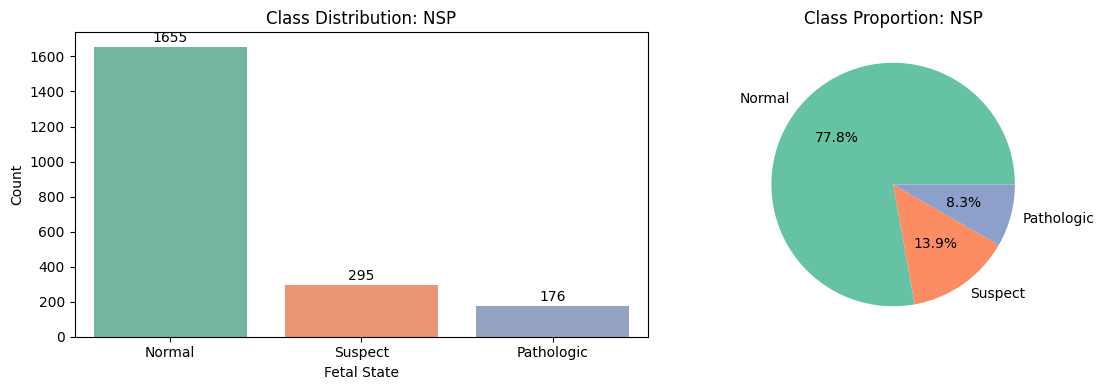

Findings — Target Distribution

  - Normal: ~78% (1,655 cases)
  - Suspect: ~14% (295 cases)
  - Pathologic: ~8% (176 cases)


In [5]:
# 3. Exploratory Data Analysis (EDA)
"""
Explore the distribution of the target variable and features.
Args:
    df: Input DataFrame
Returns:
    None
Reference:
    https://www.geeksforgeeks.org/exploratory-data-analysis-in-python/
"""

# 3.1 Target distribution
def plot_target_distribution(df: pd.DataFrame, target_col: str = 'NSP') -> None:

    print("3. TARGET DISTRIBUTION")

    # Map numeric labels to readable names
    plot_series = df[target_col].map(NSP_LABELS)
    order = ['Normal', 'Suspect', 'Pathologic']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Count plot
    sns.countplot(x=plot_series, order=order, palette='Set2', ax=axes[0])
    axes[0].set_title(f'Class Distribution: {target_col}')
    axes[0].set_xlabel('Fetal State')
    axes[0].set_ylabel('Count')
    for bar in axes[0].patches:
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 10,
            f'{int(bar.get_height())}',
            ha='center', va='bottom', fontsize=10
        )

    # Pie chart
    counts = plot_series.value_counts().reindex(order)
    axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
                colors=sns.color_palette('Set2', len(counts)))
    axes[1].set_title(f'Class Proportion: {target_col}')

    plt.tight_layout()
    plt.show()

    # 3.1 Findings
    print('Findings — Target Distribution\n')

    for label in order:
        count = (plot_series == label).sum()
        pct = (count / len(plot_series)) * 100
        print(f'  - {label}: ~{pct:.0f}% ({count:,} cases)')

# Plot target distribution
plot_target_distribution(df, 'NSP')

The dataset is **imbalanced**:
**Modeling consideration:** Accuracy alone is misleading here. We will use **macro F1-score** and **stratified splits** to ensure minority classes are represented. Classifiers will use `class_weight='balanced'`.

 FEATURE DISTRIBUTIONS — Overview


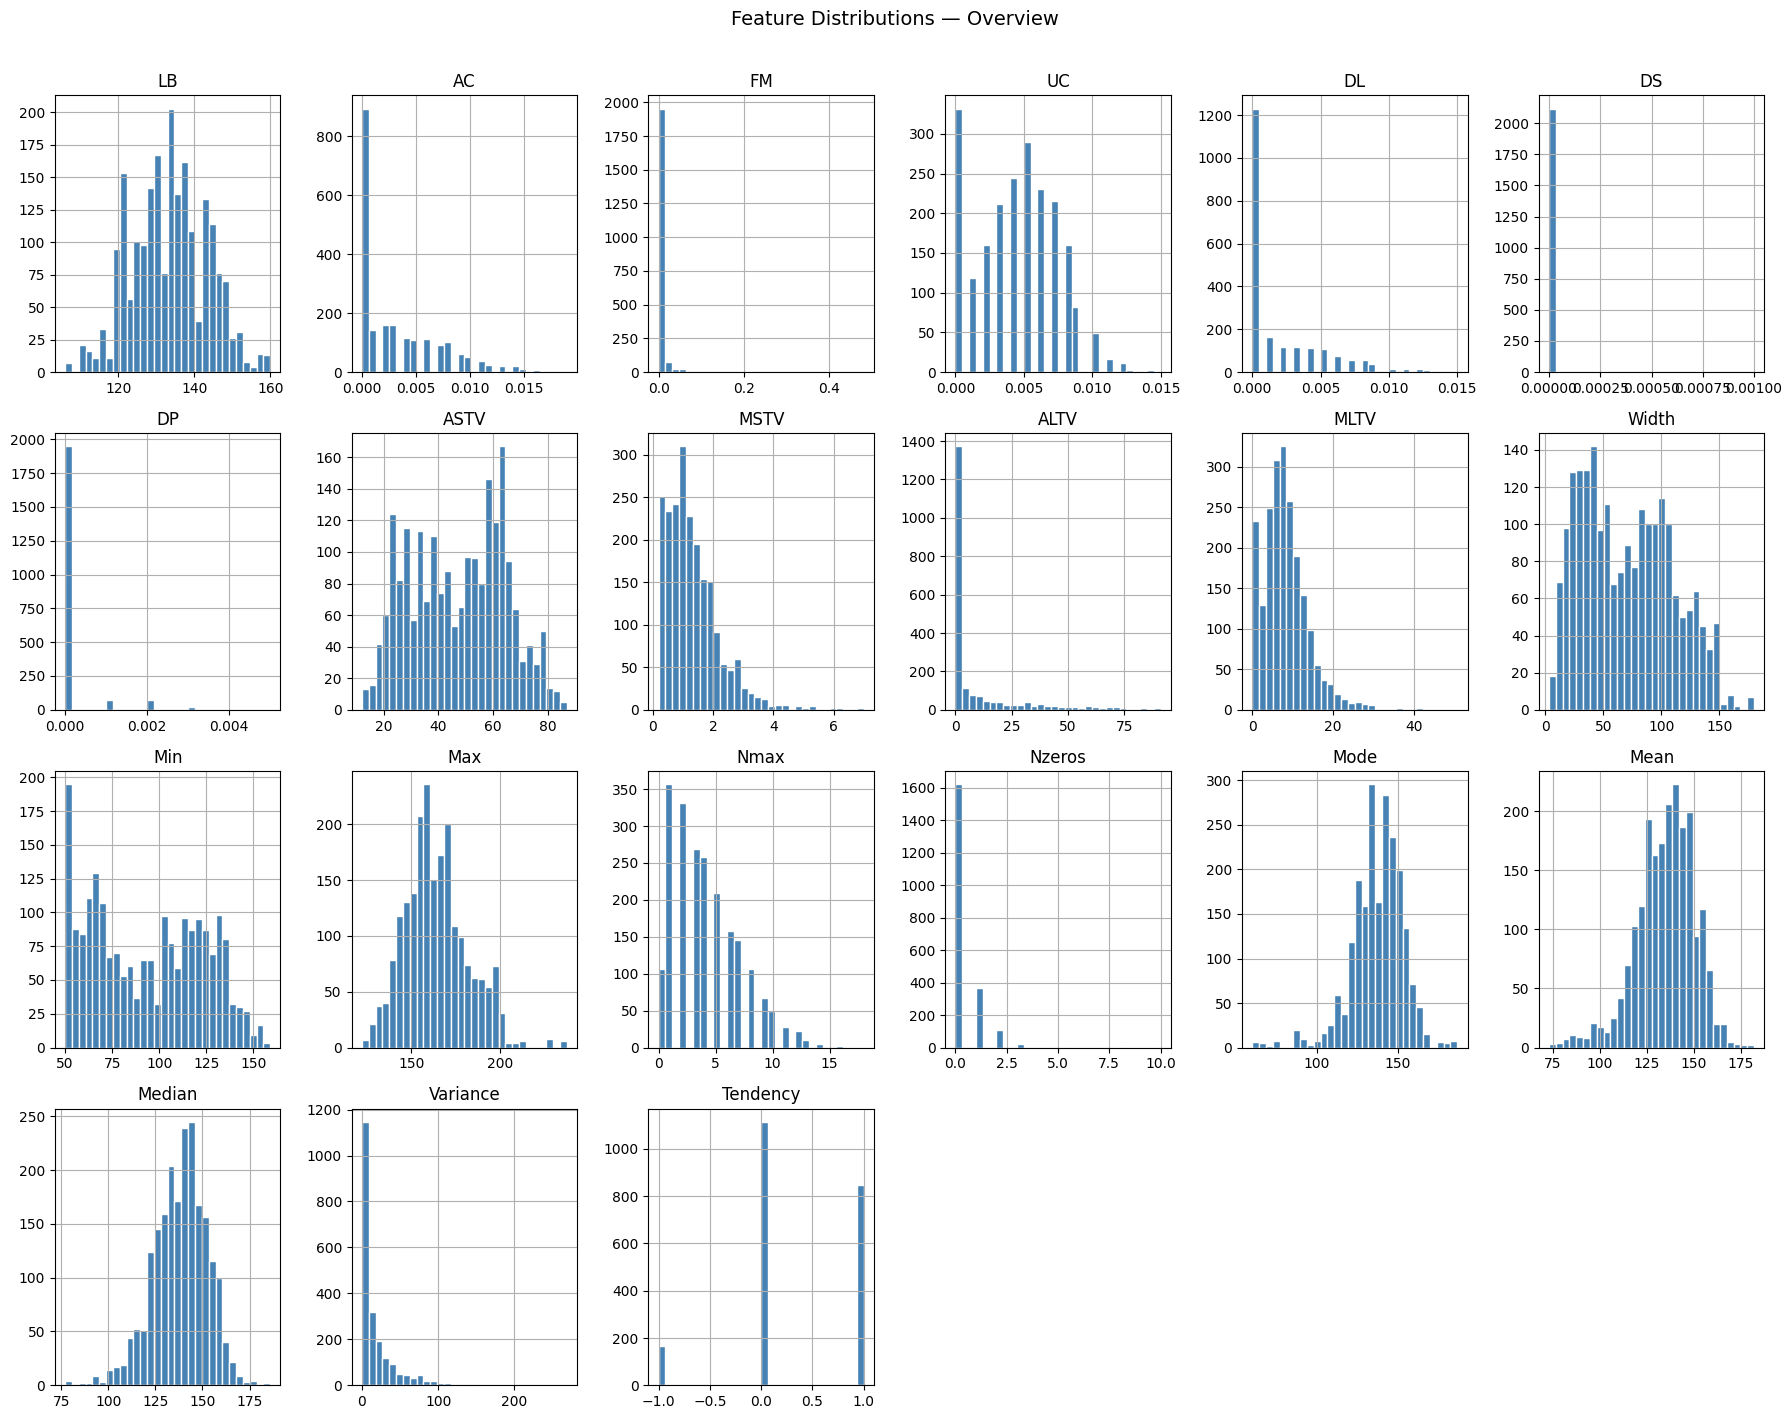

 FEATURE DISTRIBUTIONS — Statistical Markers


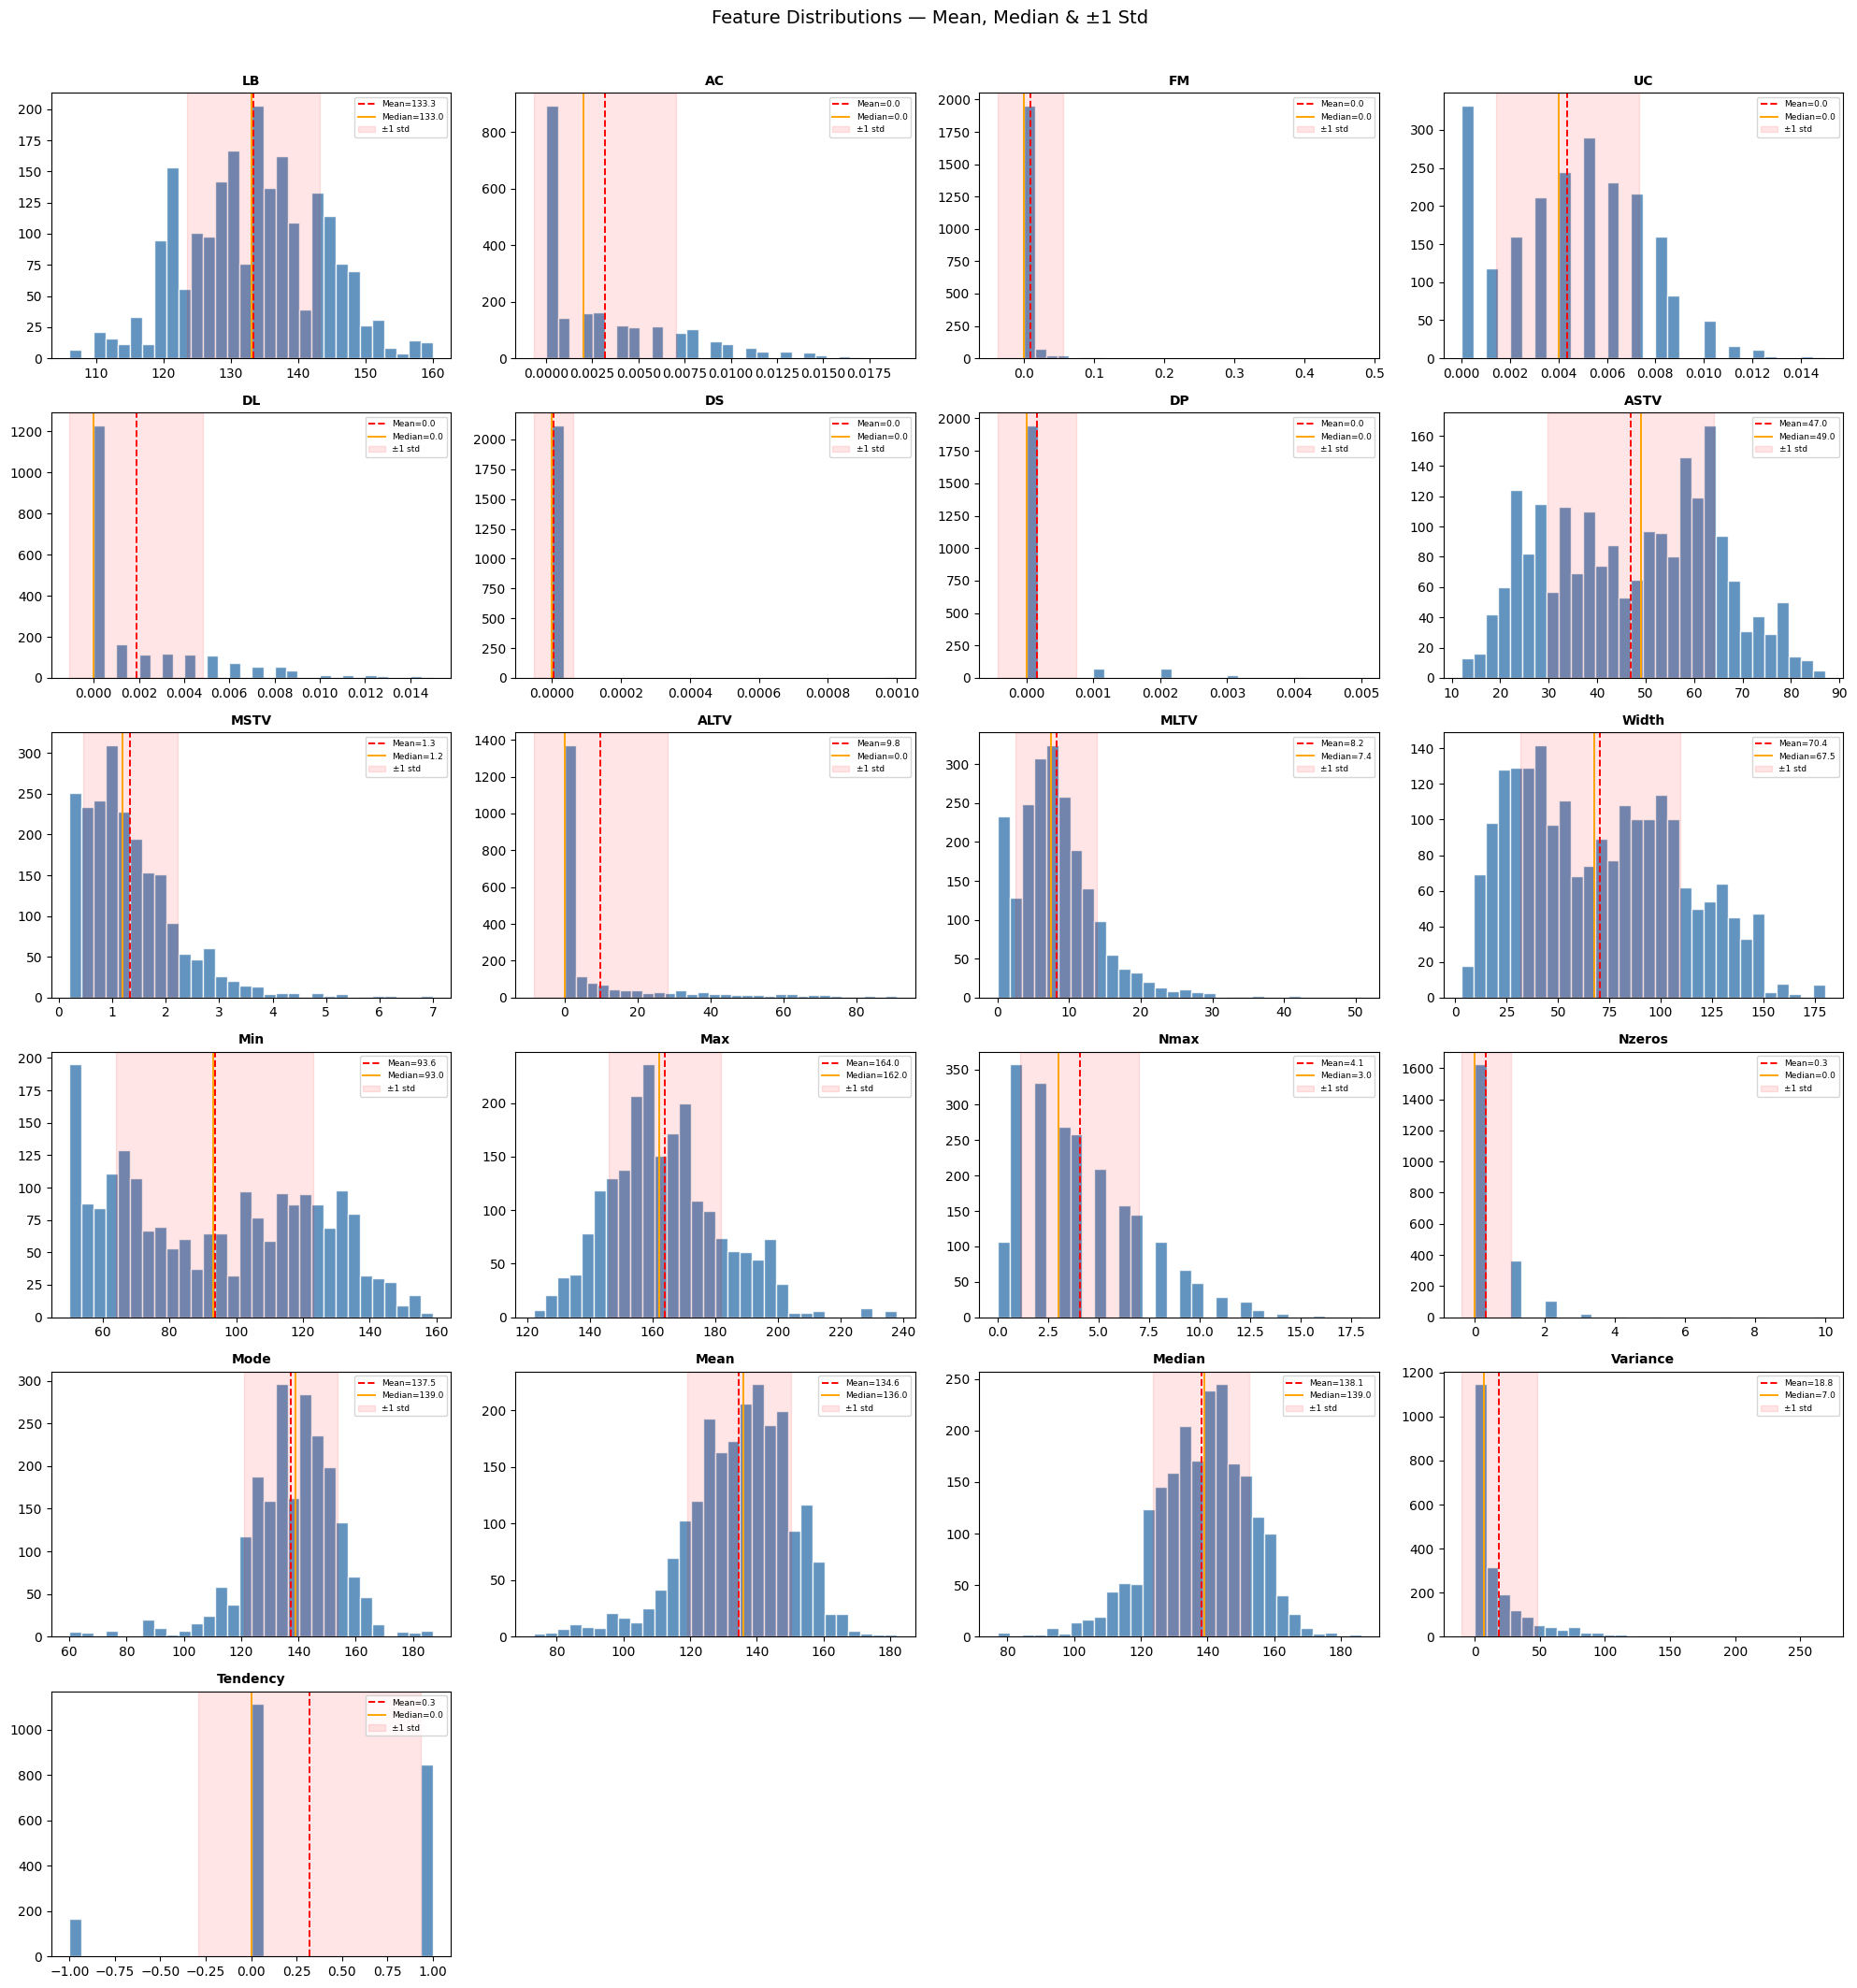


Highly skewed features (|skew| > 1):
DS          17.34
FM           7.81
DP           4.32
Nzeros       3.92
Variance     3.22
ALTV         2.19
DL           1.72
MSTV         1.66
MLTV         1.33
AC           1.20


In [6]:
# 3.2 Feature distributions
from scipy.stats import skew
"""
Plot histograms for all numerical features to understand
their distributions and spot potential outliers.
"""

# 3.2.1 Basic feature distributions
def plot_feature_distributions(df: pd.DataFrame) -> None:
    """
    Plot basic histograms for a quick overview of all feature distributions.
    """
    print(" FEATURE DISTRIBUTIONS — Overview")

    feature_cols = [c for c in df.columns if c not in CTG_TARGET_COLS]

    df[feature_cols].hist(
        bins=30,
        figsize=(18, 14),
        color='steelblue',
        edgecolor='white',
        layout=(4, 6)
    )
    plt.suptitle('Feature Distributions — Overview', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


# 3.2.2 Enhanced feature distributions with statistical markers
def plot_feature_distributions_stats(df: pd.DataFrame) -> None:
    """
    Plot histograms with mean, median, and ±1 std markers
    to identify skewness and outliers per feature.
    """
    print(" FEATURE DISTRIBUTIONS — Statistical Markers")

    feature_cols = [c for c in df.columns if c not in CTG_TARGET_COLS]

    n_cols = 4
    n_rows = -(-len(feature_cols) // n_cols)  # ceiling division

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
    axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        ax = axes[i]
        data = df[col].dropna()

        col_mean   = data.mean()
        col_median = data.median()
        col_std    = data.std()

        # Histogram
        ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.85)

        # Mean line
        ax.axvline(col_mean,   color='red',    linestyle='--', linewidth=1.4,
                   label=f'Mean={col_mean:.1f}')
        # Median line
        ax.axvline(col_median, color='orange', linestyle='-',  linewidth=1.4,
                   label=f'Median={col_median:.1f}')
        # ±1 std shaded band
        ax.axvspan(col_mean - col_std, col_mean + col_std,
                   alpha=0.10, color='red', label='±1 std')

        ax.set_title(col, fontsize=10, fontweight='bold')
        ax.set_xlabel('')
        ax.legend(fontsize=6.5, loc='upper right')

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Feature Distributions — Mean, Median & ±1 Std',
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    # Flag skewed features
    skewness = df[feature_cols].apply(skew).sort_values(ascending=False)
    highly_skewed = skewness[abs(skewness) > 1]

    print('\nHighly skewed features (|skew| > 1):')
    print(highly_skewed.round(2).to_string())


# Run both
plot_feature_distributions(df)
plot_feature_distributions_stats(df)

### 3.2 Findings — Feature Distributions

| Feature(s) | Shape | What it means |
|-----------|-------|---------------|
| `LB`, `Mean`, `Median`, `Mode`, `Min`, `Max` | Normal / Symmetric | Stable bell-shaped distributions — strong predictive candidates |
| `AC`, `FM`, `UC`, `DL`, `DS`, `DP`, `Variance`, `Width` | Right-Skewed | Mass near zero with long tails — zeros reflect normal clinical absence of those events |
| `ASTV`, `MSTV`, `ALTV`, `MLTV` | Multi-Modal | Wide spreads or multi-peak patterns — likely represent distinct physiological states across patients |
| `Nmax`, `Nzeros` | Discrete / Sparse | Integer event counts with low variance — potentially weak standalone predictors |
| `Tendency` | Discrete / Sparse | Clusters at `-1`, `0`, `+1` — acts as a direction indicator |
| `DL`, `DS`, `DP`, `Variance`, `Width` | Extreme Outliers | Sparse extreme values — may require clipping or robust scaling for linear models |

3.4 FEATURE DISTRIBUTIONS BY CLASS


/tmp/ipykernel_12352/1093094088.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_12352/1093094088.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_12352/1093094088.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_12352/1093094088.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_12352/1093094088.py:22: FutureWarning

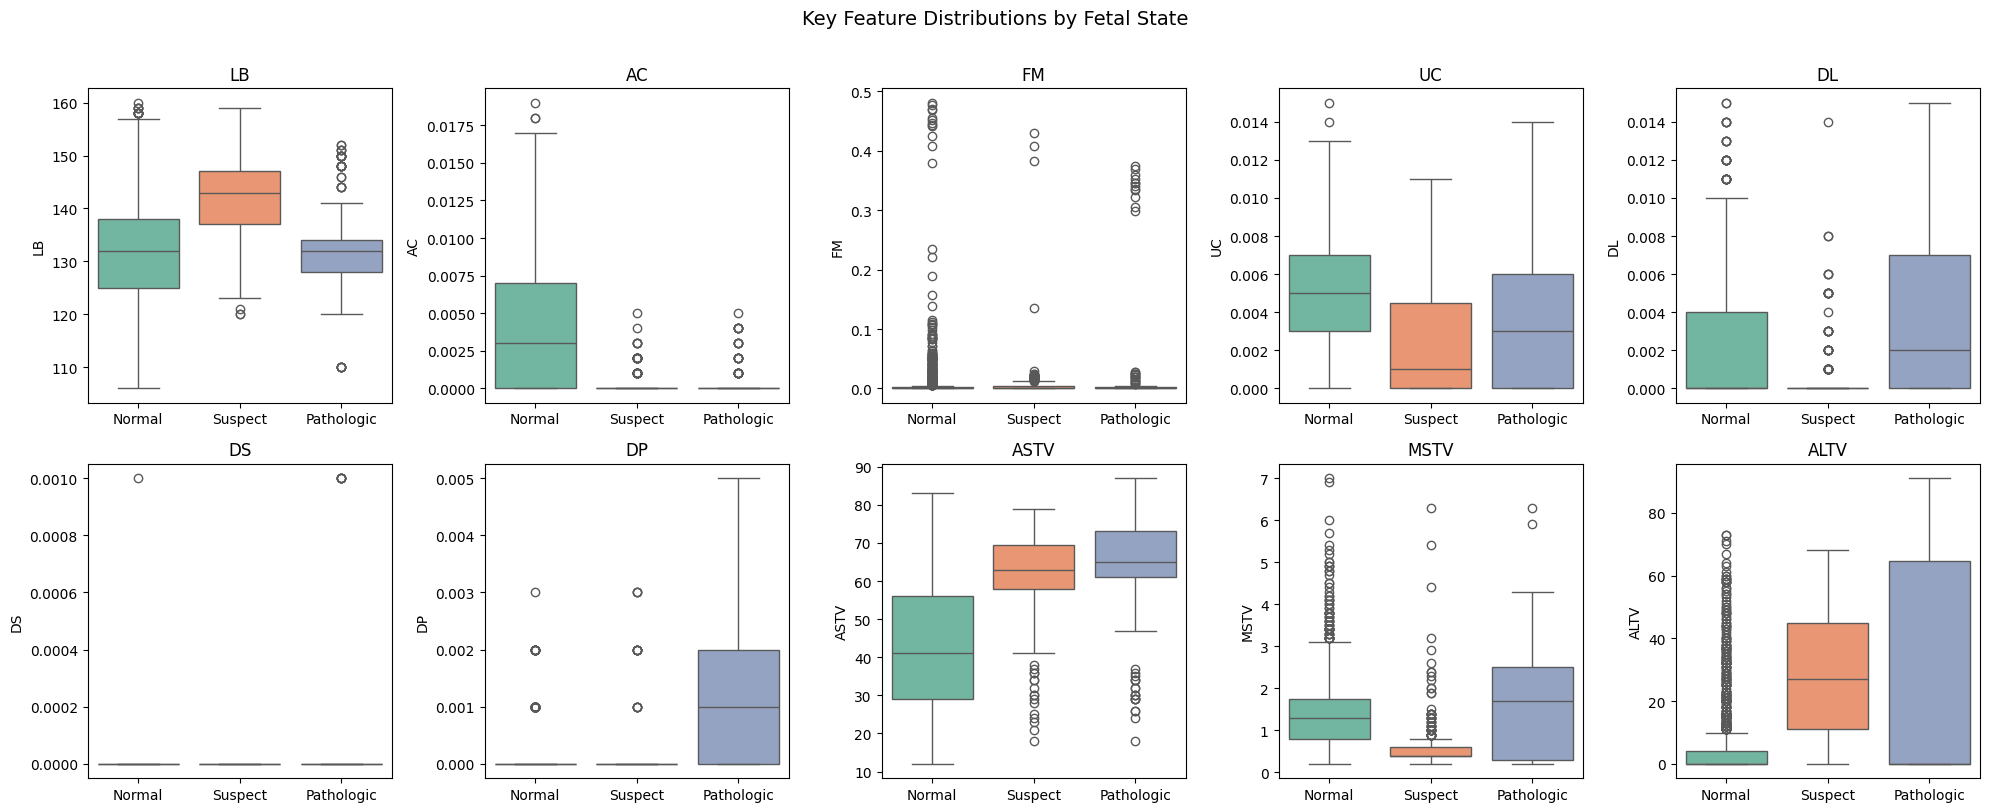

In [7]:
# 3.3 Feature distributions by class
"""
Plot boxplots for key clinical features grouped by NSP class
to visualize how features differ across fetal states.
"""

def plot_features_by_class(df: pd.DataFrame, target_col: str = 'NSP') -> None:

    print("3.4 FEATURE DISTRIBUTIONS BY CLASS")

    # Key clinical features to compare
    key_features = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV']

    plot_df = df.copy()
    plot_df[target_col] = plot_df[target_col].map(NSP_LABELS)
    order = ['Normal', 'Suspect', 'Pathologic']

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()

    for i, feature in enumerate(key_features):
        sns.boxplot(
            data=plot_df,
            x=target_col,
            y=feature,
            order=order,
            palette='Set2',
            ax=axes[i]
        )
        axes[i].set_title(feature)
        axes[i].set_xlabel('')

    plt.suptitle('Key Feature Distributions by Fetal State', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

# Plot features by class
plot_features_by_class(df, 'NSP')

### 3.3 Findings — Feature Distributions by Class

#### Feature Separability Summary

| Feature | Normal | Suspect | Pathologic | Tier | Clinical Meaning |
|---------|--------|---------|------------|------|-----------------|
| `ASTV` | Low | Higher | Very High (~80-90%) | S | Abnormal short-term variability — strongest separator |
| `ALTV` | Small | Moderate | Very high spread | S | Abnormal long-term variability — direct fetal compromise |
| `LB` | ~130-140 bpm | Slightly higher | ~110-120 bpm | S | Depressed baseline FHR = distress indicator |
| `AC` | Highest | Near zero | Near zero | S | Loss of accelerations = hallmark of fetal distress |
| `DL` | Near zero | Slightly higher | Much higher | S | More frequent decelerations = higher risk |
| `DP` | Near zero | Near zero | Wide/High range | S | Prolonged decelerations = severe distress |
| `MSTV` | Smallest | Moderate | Noticeably larger | A | Good directional separation |
| `UC` | Low/tight | Intermediate | High/spread | A | Higher contractions correlate with fetal stress |
| `FM` | Near zero | Near zero | Near zero + outliers | B | Weak separator — similar across all classes |
| `DS` | Near zero | Near zero | Rare outliers | B | Sparse but highly significant when present |

---

#### Overall Fetal State Pattern

| Characteristic | Normal | Suspect | Pathologic |
|----------------|--------|---------|------------|
| Baseline FHR (`LB`) | Stable ~130-140 bpm | Slightly shifted | Depressed ~110-120 bpm |
| Accelerations (`AC`) | High | Low | Near absent |
| Variability (`ASTV`, `ALTV`) | Low/tight | Moderate | Very high/unstable |
| Decelerations (`DL`, `DP`) | Minimal | Occasional | Frequent/severe |
| Contractions (`UC`) | Low | Moderate | High |
| Distribution spread | Tight | Intermediate | Wide/erratic |

---

> **Modeling Considerations:**
> - **Top features:** `ASTV`, `ALTV`, `AC`, `LB`, `DL`, `DP` — use all in initial model
> - `FM`, `DS` are weak predictors but it may contribute in ensemble models
> - Heavy outliers in `DP`, `FM`, `DS` favor **tree-based models** (Random Forest, XGBoost)
> - Suspect class sits predictably between Normal and Pathologic — consistent with clinical CTG guidelines

**Multicollinearity Check**

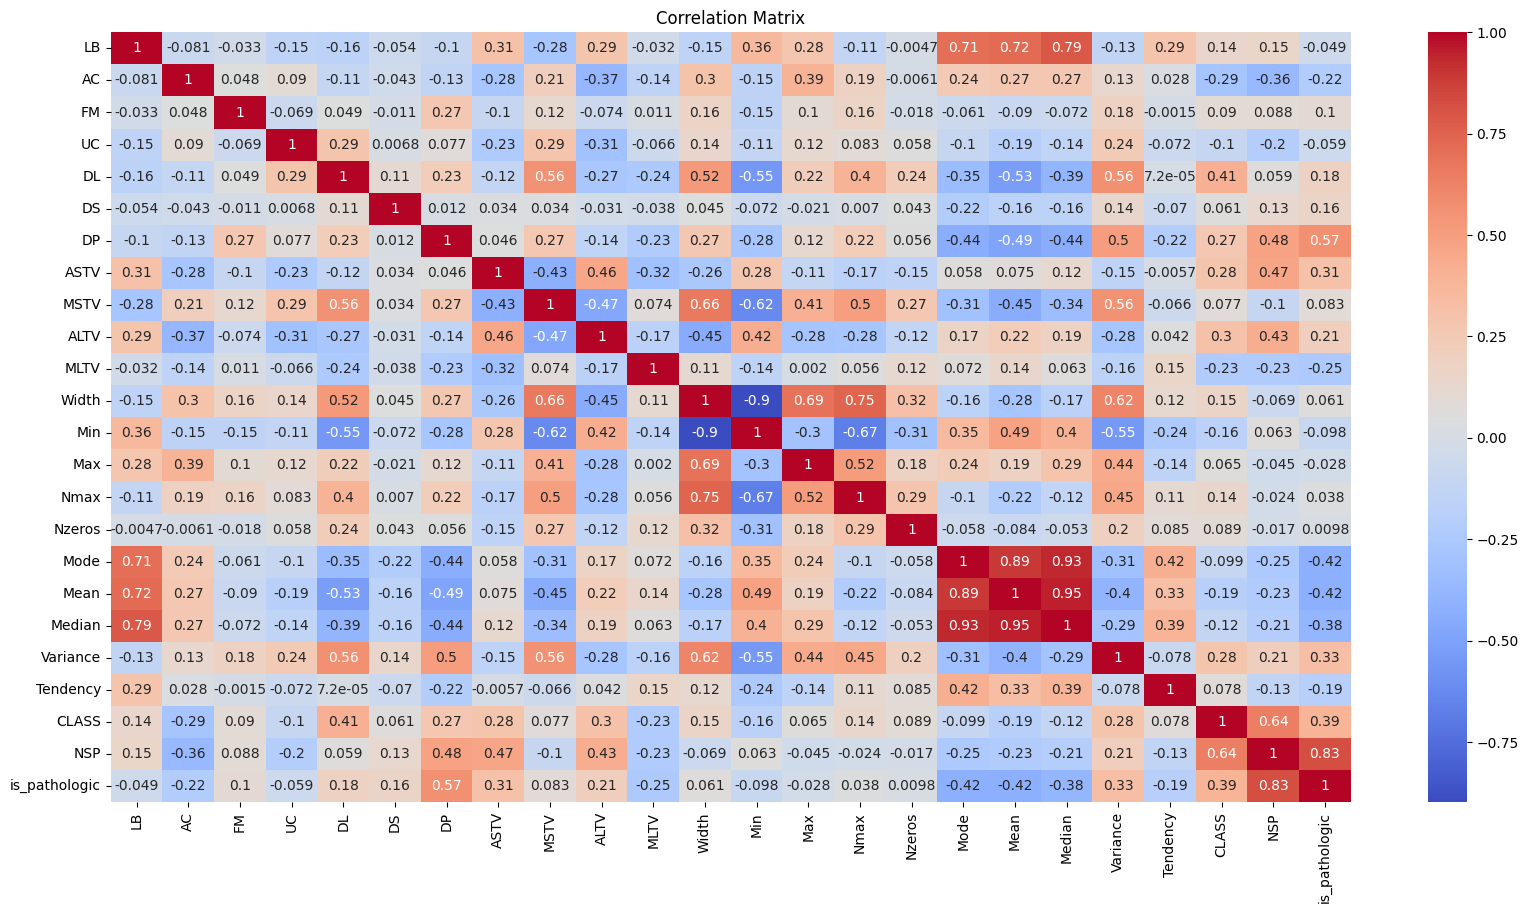

In [8]:
# 3.4.1 Correlation Matrix
"""
Create correlation matrix to see relationship between
features and target.
"""

# Create correlation matrix
correlation_df = df.copy()
correlation_df['is_pathologic'] = (correlation_df['NSP'] == 3).astype(int)
correlation_matrix = correlation_df.corr()

# Plot correlation matrix
plt.figure(figsize = (20,10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [9]:
# 3.4.2 Sort features by most to least correlated to target

correlation = correlation_matrix['is_pathologic'].abs().sort_values(ascending = False)
print(correlation)

is_pathologic    1.000000
NSP              0.829370
DP               0.567540
Mode             0.419051
Mean             0.416886
CLASS            0.385971
Median           0.384857
Variance         0.331060
ASTV             0.306735
MLTV             0.245545
AC               0.216591
ALTV             0.212343
Tendency         0.193919
DL               0.180793
DS               0.161516
FM               0.104288
Min              0.097555
MSTV             0.082600
Width            0.060945
UC               0.059397
LB               0.049357
Nmax             0.038205
Max              0.028399
Nzeros           0.009780
Name: is_pathologic, dtype: float64


**Interpretation:** Tree are robust to multicollinearity, adjusting for feature relevance. If we are to use logit/regression analysis, we would have to select features to reduce redundancy.

## EDA Summary — Key Findings & Modeling Decisions

---

### 1. The Dataset is Unbalanced
Most recordings in this dataset are from healthy fetuses:
- **Normal: ~78%** (1,655 cases)
- **Suspect: ~14%** (295 cases)
- **Pathologic: ~8%** (176 cases)

This matters because a model could simply predict like "Normal" every time and still be 78% accurate — while completely missing every dangerous case.

**What we should consider @Jasmine & @Lashana REVIEW THIS :**
- Measure model performance using macro F1-score (treats all three classes equally)
- Use stratified splits (keeps the same class proportions in train and test sets)
- Tell the model to pay more attention to rare classes using `class_weight='balanced'`

---

### 2. Features Have Very Different Scales and Shapes
Some features like `LB` (heart rate) range from 100–180, while others like `DS` (severe decelerations) are almost always zero with rare spikes.

**What we will do:**
- For **linear models** (Logistic Regression, SVM): normalize all features to the same scale using `StandardScaler`, and apply log/sqrt transformation to compress the extreme values in `AC`, `FM`, `DS`, `DP`, `Variance`
- For **tree-based models** (Random Forest, XGBoost): no transformation needed because these models handle uneven scales and skewed data naturaly

---

### 3. Some Features Have Extreme Outliers
Features like `DS`, `DP`, `FM`, `Variance`, and `Width` are near zero for most patients but occasionally show very large values. These are not errors but they represent rare but clinically significant events.

**What we will do:**
- Prefer **tree-based models** which are robust to these extreme values

---

### 4. Most Useful Features for Prediction

| Feature | What it measures | Why it matters |
|---------|-----------------|----------------|
| `ASTV` | % of time with abnormal short-term heart rate variability | Much higher in Pathologic cases — strongest signal |
| `AC` | Number of accelerations (heart rate speeding up) | Nearly absent in Pathologic cases |
| `LB` | Baseline fetal heart rate | Lower in Pathologic cases — sign of distress |
| `DP` | Prolonged decelerations (heart rate drops) | More frequent and severe in Pathologic cases |
| `ALTV` | % of time with abnormal long-term variability | Directly linked to fetal compromise |
| `Mean`, `Median` | Average heart rate statistics | Stable and consistent signal across recordings |
| `MLTV`, `Variance` | Variability measures | Capture how erratic the heart rate pattern is |

**Split training and test data and create pipeline**

In [10]:
# 4 Split training and test data and create pipeline
"""
Split the data into training and testing sets
and prepare for model testing.
"""

target = 'NSP'

# separate target column
X = df.drop(columns=[target, 'CLASS'])
y = df[target].astype(int)-1

from sklearn.model_selection import train_test_split

# create training and test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42, stratify = y
)


**Class-balance the training data only via SMOTE**

In [11]:
%%capture
!pip install imblearn

In [12]:
# 3.5 Bootstrapping the training data only
"""
Using SMOTE in order to generate synthetic minority samples
"""
from imblearn.over_sampling import SMOTE

X = df.drop(columns=['NSP'])
y = df['NSP']

# apply SMOTE only on training set
smote = SMOTE(random_state = 42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

smote_df = pd.concat([X_resampled, y_resampled], axis = 1)
smote_df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,NSP
0,140,0.000,0.000,0.001,0.000,0.0,0.0,60,0.8,32,11.2,120,79,199,9,0,141,141,142,3,0,1
1,123,0.006,0.000,0.006,0.004,0.0,0.0,33,1.3,0,4.7,138,61,199,9,1,135,122,127,39,0,0
2,122,0.003,0.000,0.004,0.000,0.0,0.0,22,1.8,0,14.7,50,103,153,4,0,126,127,128,4,0,0
3,143,0.000,0.000,0.002,0.000,0.0,0.0,68,0.3,5,9.4,23,135,158,1,0,144,144,145,1,0,0
4,129,0.009,0.035,0.003,0.000,0.0,0.0,41,1.1,0,2.9,135,65,200,4,1,133,147,142,60,0,0


**EDA on the class-balanced training data**

3. TARGET DISTRIBUTION


/tmp/ipykernel_12352/1323473275.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=plot_series, order=order, palette='Set2', ax=axes[0])


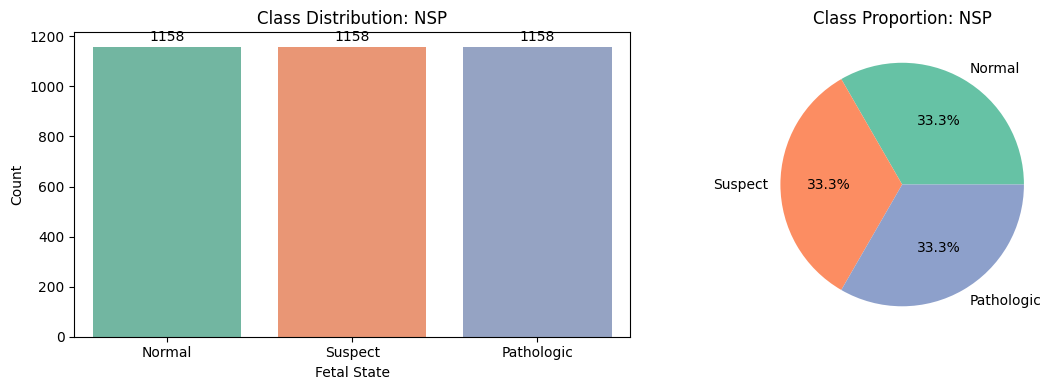

Findings — Target Distribution

  - Normal: ~33% (1,158 cases)
  - Suspect: ~33% (1,158 cases)
  - Pathologic: ~33% (1,158 cases)


In [13]:
# Replot the distribution of the target variable
# Create a temporary DataFrame for plotting with 1-indexed NSP values
smote_df_plot = smote_df.copy()
smote_df_plot['NSP'] = smote_df_plot['NSP'] + 1
plot_target_distribution(smote_df_plot, 'NSP')

3.4 FEATURE DISTRIBUTIONS BY CLASS


/tmp/ipykernel_12352/2377974436.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_12352/2377974436.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_12352/2377974436.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_12352/2377974436.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_12352/2377974436.py:24: FutureWarning

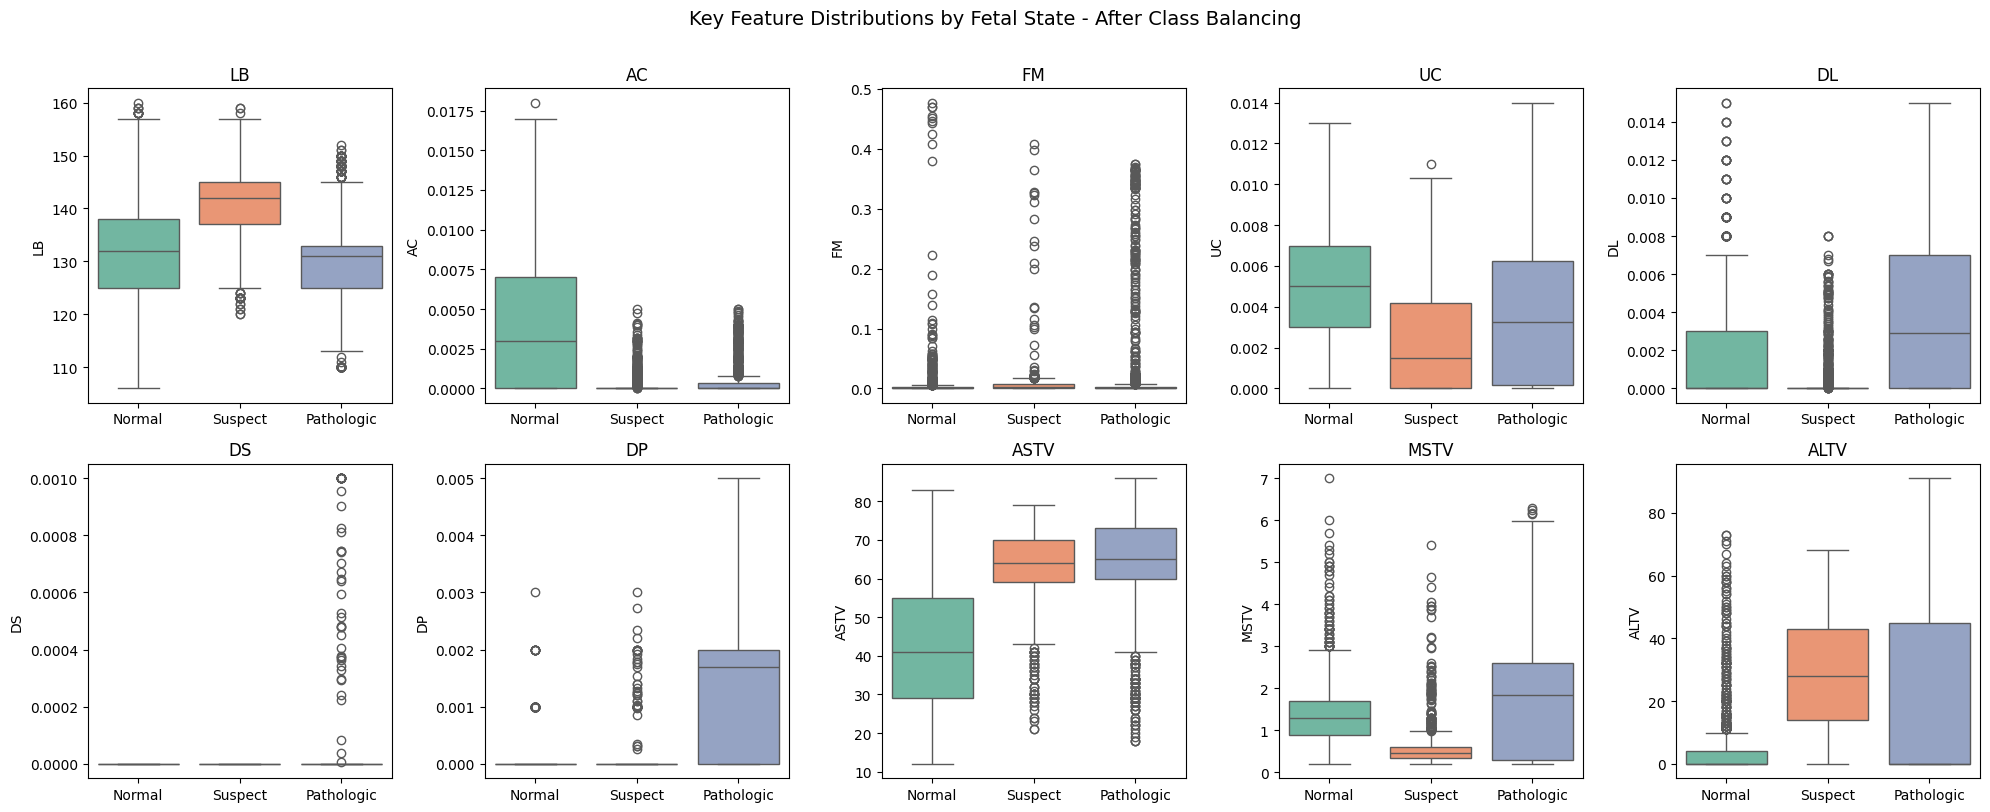

In [56]:
# 3.3 Feature distributions by class - using smote balanced data
"""
Plot boxplots for key clinical features grouped by NSP class
to visualize how features differ across fetal states.
"""

def plot_features_by_class(df: smote_df, target_col: str = 'NSP') -> None:

    print("3.4 FEATURE DISTRIBUTIONS BY CLASS")

    # Key clinical features to compare
    key_features = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV']

    plot_df = smote_df.copy()
    plot_df['NSP'] = plot_df['NSP'] + 1

    plot_df[target_col] = plot_df[target_col].map(NSP_LABELS)
    order = ['Normal', 'Suspect', 'Pathologic']

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()

    for i, feature in enumerate(key_features):
        sns.boxplot(
            data=plot_df,
            x=target_col,
            y=feature,
            order=order,
            palette='Set2',
            ax=axes[i]
        )
        axes[i].set_title(feature)
        axes[i].set_xlabel('')

    plt.suptitle('Key Feature Distributions by Fetal State - After Class Balancing', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

# Plot features by class
plot_features_by_class(df, 'NSP')

# Structured Learning Models

**Evaluating 3 model: SVM, Random Forest, and XGBoost**

In [20]:
# 4.1 SVM Model Testing
from sklearn import svm
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, recall_score, precision_score # Import metrics

# create SVM model
linear_model = svm.SVC(kernel = 'linear', class_weight='balanced')

# use pipeline in order to scale columns
pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("feature_selection", SelectKBest(f_classif)),
    ("model", linear_model)
])

pipe.fit(X_train, y_train)
y_pred_svm = pipe.predict(X_test) # Renamed to y_pred_svm

# calculate evaluation metrics
svm_f1 = f1_score(y_test, y_pred_svm, average='macro')
svm_recall = recall_score(y_test, y_pred_svm, average='macro')
svm_precision = precision_score(y_test, y_pred_svm, average='macro')

In [23]:
# 4.2 Random Forest Testing
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel # Import SelectFromModel
from sklearn.metrics import f1_score, recall_score, precision_score # Import metrics
from sklearn.pipeline import Pipeline # Import Pipeline
from sklearn.preprocessing import StandardScaler # Import StandardScaler

# create Random Forest model
random_forest = RandomForestClassifier(class_weight='balanced')

pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("feature_selection", SelectFromModel(RandomForestClassifier(class_weight='balanced'))),
    ("model", random_forest)
])

pipe.fit(X_train, y_train)
y_pred_rf = pipe.predict(X_test) # Renamed to y_pred_rf

# calculate evaluation metrics
rf_f1 = f1_score(y_test, y_pred_rf, average='macro')
rf_recall = recall_score(y_test, y_pred_rf, average='macro')
rf_precision = precision_score(y_test, y_pred_rf, average='macro')

In [31]:
# 4.3 XGBoost Model Testing
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline # Import Pipeline
from sklearn.feature_selection import SelectFromModel # Import SelectFromModel
from sklearn.preprocessing import StandardScaler # Import StandardScaler

# create XGBoost model
xgb_model = xgb.XGBClassifier()
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

# use GridSearch to find best hyperparameters
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    cv = 5,
    scoring='f1_macro'
)

pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ('selector', SelectFromModel(XGBClassifier(random_state=42))),
    ("model", grid_search)
])

pipe.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}


In [33]:
# create new XGBoost model with best parameters
import xgboost as xgb
from sklearn.metrics import f1_score, recall_score, precision_score # Import metrics

xgb_fitted_model = xgb.XGBClassifier(
    max_depth = 5,
    learning_rate = 0.2,
    n_estimators = 200,
    random_state = 42
)

# fit test and training data to new model
xgb_fitted_model.fit(X_train, y_train)

# test new model
y_fit_pred = xgb_fitted_model.predict(X_test)

# calculate XGBoost evaluation metrics
xgb_f1 = f1_score(y_test, y_fit_pred, average='macro')
xgb_recall = recall_score(y_test, y_fit_pred, average='macro')
xgb_precision = precision_score(y_test, y_fit_pred, average = 'macro')

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


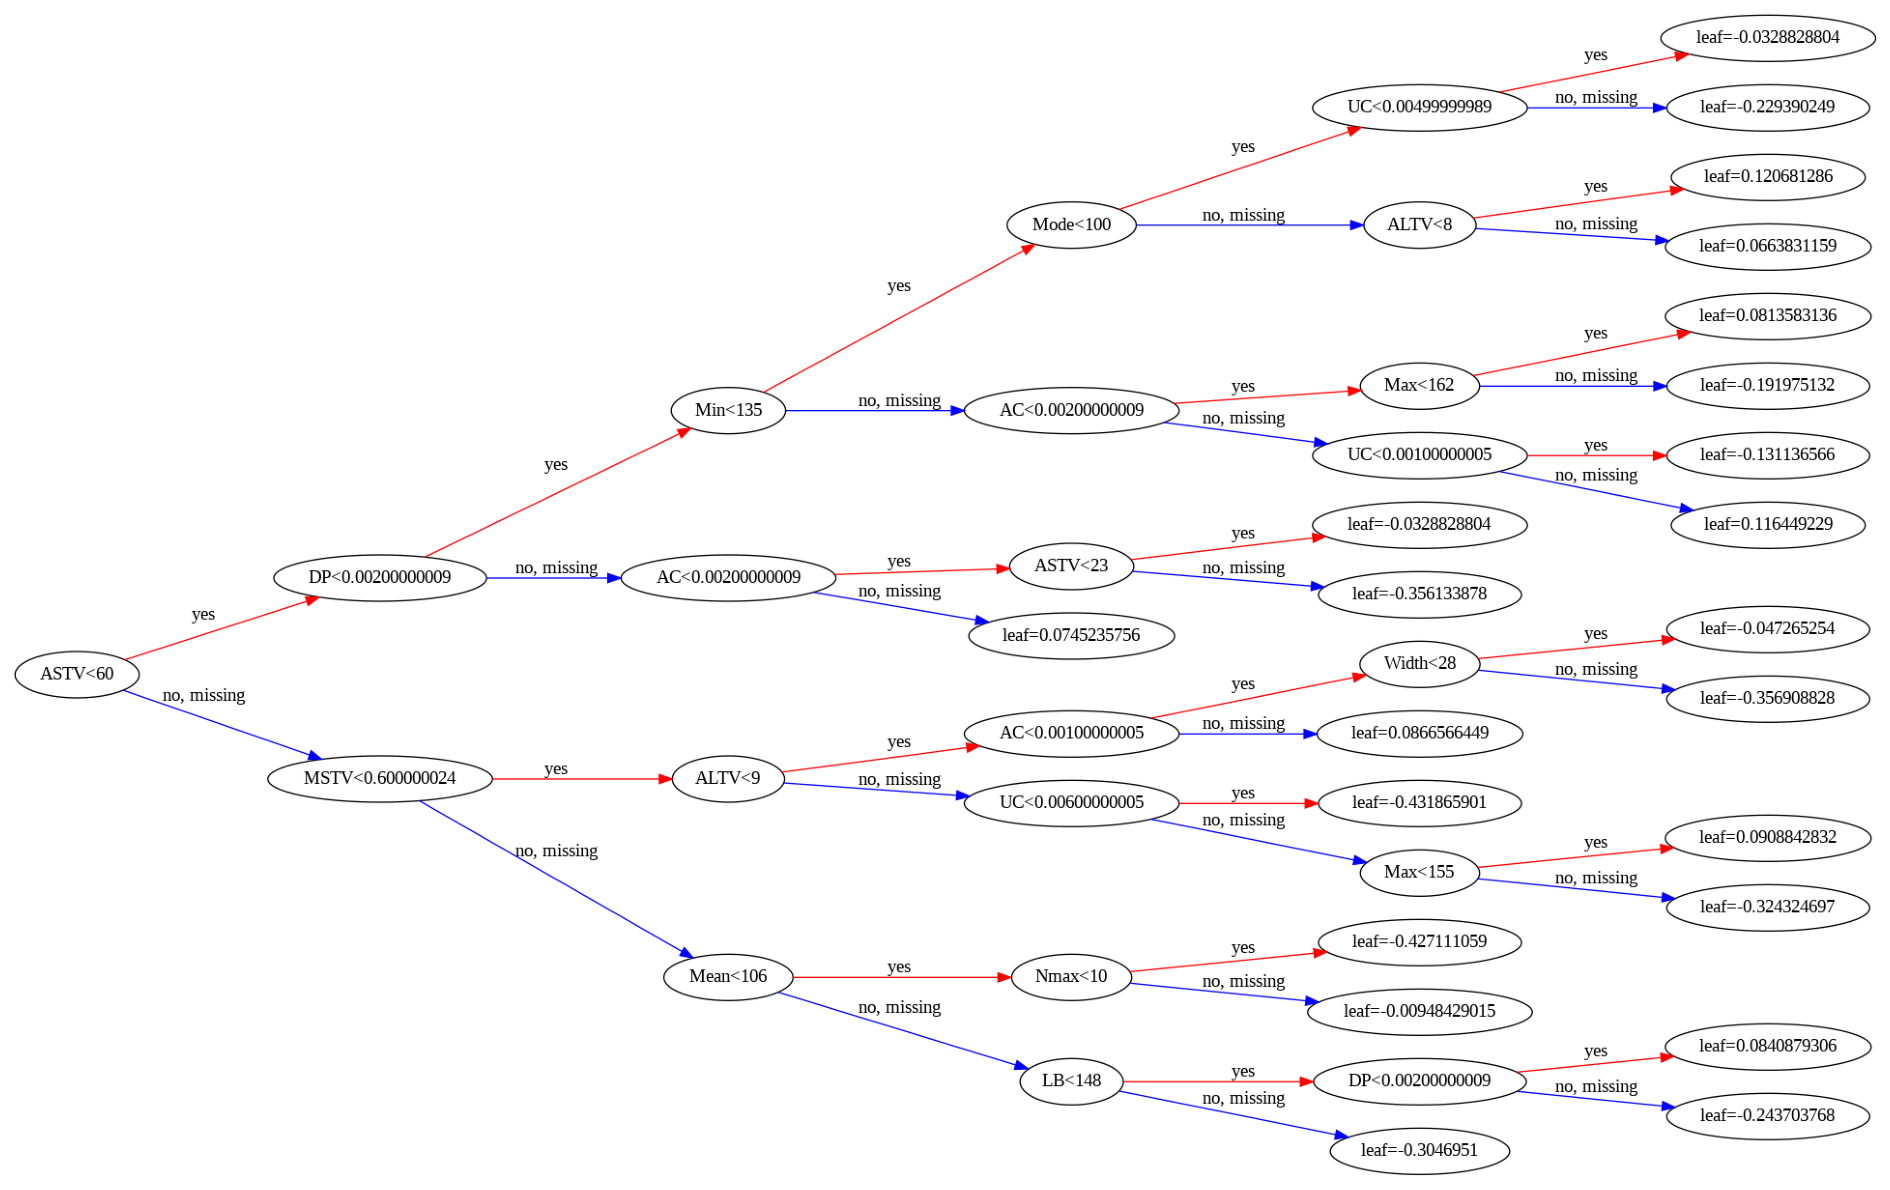

In [34]:
import matplotlib.pyplot as plt
import xgboost as xgb

fig, ax = plt.subplots(figsize=(24, 12))
xgb.plot_tree(xgb_fitted_model, num_trees=0, rankdir='LR', ax=ax)
plt.tight_layout()
plt.show()

In [35]:
# create DataFrame of evaluation metrics
import pandas as pd # Ensure pandas is imported
scores = pd.DataFrame({"Model": ["Linear SVM", "Random Forest", "XGBoost"],
                      "F1 Score": [svm_f1, rf_f1, xgb_f1],
                      "Recall Score": [svm_recall, rf_recall, xgb_recall],
                      "Precision Score": [svm_precision, rf_precision, xgb_precision]})
# sort by f1 scores
scores = scores.sort_values(by = 'F1 Score', ascending = False)
scores

,Model,F1 Score,Recall Score,Precision Score
2,XGBoost,0.900625,0.884187,0.922647
1,Random Forest,0.858007,0.846687,0.876246
0,Linear SVM,0.746879,0.814236,0.716630



--- Linear SVM Evaluation ---


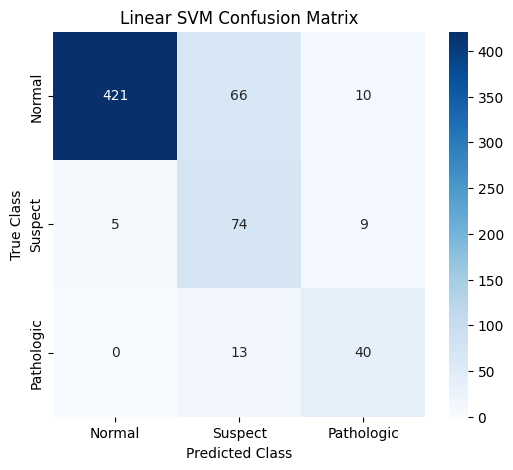

Classification Report:

              precision    recall  f1-score   support

      Normal      0.988     0.847     0.912       497
     Suspect      0.484     0.841     0.614        88
  Pathologic      0.678     0.755     0.714        53

    accuracy                          0.839       638
   macro avg      0.717     0.814     0.747       638
weighted avg      0.893     0.839     0.855       638


--- Random Forest Evaluation ---


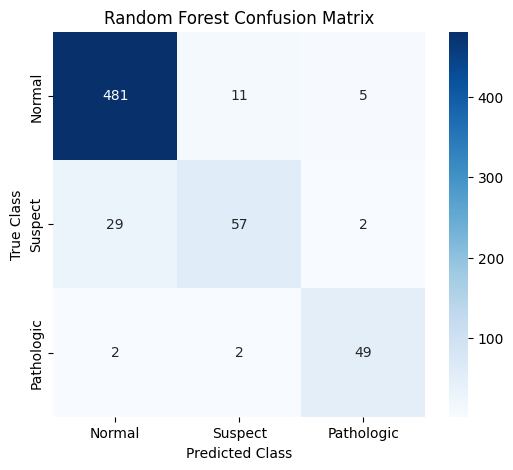

Classification Report:

              precision    recall  f1-score   support

      Normal      0.939     0.968     0.953       497
     Suspect      0.814     0.648     0.722        88
  Pathologic      0.875     0.925     0.899        53

    accuracy                          0.920       638
   macro avg      0.876     0.847     0.858       638
weighted avg      0.917     0.920     0.917       638


--- XGBoost Evaluation ---


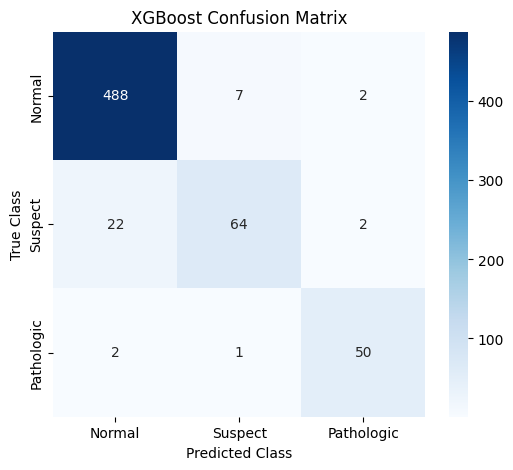

Classification Report:

              precision    recall  f1-score   support

      Normal      0.953     0.982     0.967       497
     Suspect      0.889     0.727     0.800        88
  Pathologic      0.926     0.943     0.935        53

    accuracy                          0.944       638
   macro avg      0.923     0.884     0.901       638
weighted avg      0.942     0.944     0.942       638



In [36]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score, recall_score, precision_score # Ensure all metrics are imported
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

class_names = ['Normal', 'Suspect', 'Pathologic']

def evaluate_model(model_name, y_true, y_pred_model):
    print(f"\n--- {model_name} Evaluation ---")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred_model)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    # Classification Report
    print("Classification Report:\n")
    print(classification_report(y_true, y_pred_model, target_names=class_names, digits=3))

# Linear SVM
# y_pred_svm for SVM was generated in cell 7QeU1vIGzWMg
evaluate_model('Linear SVM', y_test, y_pred_svm)

# Random Forest
# y_pred_rf for Random Forest was generated in cell dyvnE5bCzMak
evaluate_model('Random Forest', y_test, y_pred_rf)

# XGBoost
# y_fit_pred for XGBoost was generated in cell yUGnMI8Z5ZIo
evaluate_model('XGBoost', y_test, y_fit_pred)

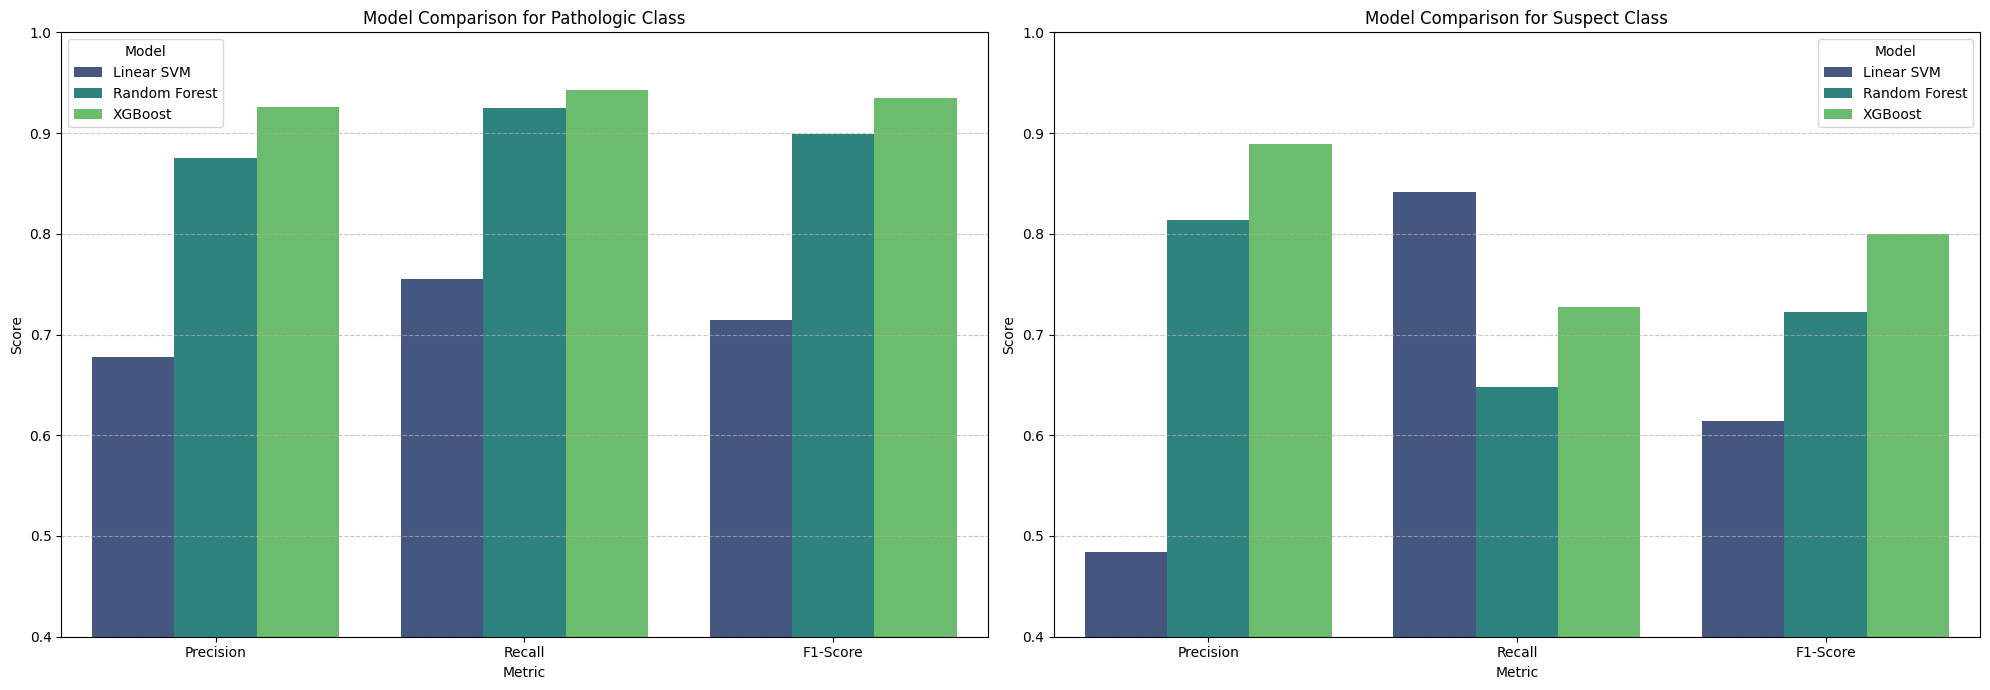

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Pathologic Class Metrics (from previous execution) ---
svm_pathologic_precision = 0.678
svm_pathologic_recall = 0.755
svm_pathologic_f1 = 0.714

rf_pathologic_precision = 0.875
rf_pathologic_recall = 0.925
rf_pathologic_f1 = 0.899

xgb_pathologic_precision = 0.926
xgb_pathologic_recall = 0.943
xgb_pathologic_f1 = 0.935

pathologic_metrics = pd.DataFrame({
    'Model': ['Linear SVM', 'Random Forest', 'XGBoost', 'Linear SVM', 'Random Forest', 'XGBoost', 'Linear SVM', 'Random Forest', 'XGBoost'],
    'Metric': ['Precision', 'Precision', 'Precision', 'Recall', 'Recall', 'Recall', 'F1-Score', 'F1-Score', 'F1-Score'],
    'Score': [
        svm_pathologic_precision, rf_pathologic_precision, xgb_pathologic_precision,
        svm_pathologic_recall, rf_pathologic_recall, xgb_pathologic_recall,
        svm_pathologic_f1, rf_pathologic_f1, xgb_pathologic_f1
    ]
})

# --- Suspect Class Metrics (extracted from classification reports) ---
# Linear SVM for Suspect class (from output of KV-K8Y84Nvv5)
svm_suspect_precision = 0.484
svm_suspect_recall = 0.841
svm_suspect_f1 = 0.614

# Random Forest for Suspect class (from output of KV-K8Y84Nvv5)
rf_suspect_precision = 0.814
rf_suspect_recall = 0.648
rf_suspect_f1 = 0.722

# XGBoost for Suspect class (from output of KV-K8Y84Nvv5)
xgb_suspect_precision = 0.889
xgb_suspect_recall = 0.727
xgb_suspect_f1 = 0.800

suspect_metrics = pd.DataFrame({
    'Model': ['Linear SVM', 'Random Forest', 'XGBoost', 'Linear SVM', 'Random Forest', 'XGBoost', 'Linear SVM', 'Random Forest', 'XGBoost'],
    'Metric': ['Precision', 'Precision', 'Precision', 'Recall', 'Recall', 'Recall', 'F1-Score', 'F1-Score', 'F1-Score'],
    'Score': [
        svm_suspect_precision, rf_suspect_precision, xgb_suspect_precision,
        svm_suspect_recall, rf_suspect_recall, xgb_suspect_recall,
        svm_suspect_f1, rf_suspect_f1, xgb_suspect_f1
    ]
})

# --- Plotting side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot for Pathologic Class
sns.barplot(x='Metric', y='Score', hue='Model', data=pathologic_metrics, palette='viridis', ax=axes[0])
axes[0].set_title('Model Comparison for Pathologic Class')
axes[0].set_xlabel('Metric')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.4, 1.0) # Start y-axis from 0.4 as requested
axes[0].legend(title='Model')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot for Suspect Class
sns.barplot(x='Metric', y='Score', hue='Model', data=suspect_metrics, palette='viridis', ax=axes[1])
axes[1].set_title('Model Comparison for Suspect Class')
axes[1].set_xlabel('Metric')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0.4, 1.0) # Start y-axis from 0.4 as requested
axes[1].legend(title='Model')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**c - Cross-validation for model stability**

In [51]:
# Cross validation on the training data, across all three classes
# The function uses the training data and splits it into 5 folds. Trains on 4 out 5 folds and compares against the remining fold (train fold).
# In the table below, fold 1 is training on folds 2-5 and tested on 1.

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier

# Ensure y_train is 0-indexed for XGBoost (y_train is already 0-indexed from previous splits)

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        max_depth=5,
        learning_rate=0.2,
        n_estimators=200,
        random_state=42,
        eval_metric='mlogloss',
        num_class=len(y_train.unique()) # Explicitly define the number of classes based on y_train
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'f1_macro': 'f1_macro',
    'recall_macro': 'recall_macro',
    'precision_macro': 'precision_macro'
}

cv_results = cross_validate(
    pipeline,
    X_train, # Use training features for cross-validation
    y_train, # Use training target variable for cross-validation
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

cv_fold_results = pd.DataFrame({
    'Fold': range(1, 6),
    'Train F1 Macro': cv_results['train_f1_macro'],
    'Test F1 Macro': cv_results['test_f1_macro'],
    'Train Recall Macro': cv_results['train_recall_macro'],
    'Test Recall Macro': cv_results['test_recall_macro'],
    'Train Precision Macro': cv_results['train_precision_macro'],
    'Test Precision Macro': cv_results['test_precision_macro']
})

print("Cross-validation results for Training Data (macro):")
display(cv_fold_results)

print("\nMean Cross-validation scores for Training Data:")
mean_scores_cv = cv_fold_results.drop('Fold', axis=1).mean().to_frame(name='Mean Score')
display(mean_scores_cv)

Cross-validation results for Training Data (macro):


,Fold,Train F1 Macro,Test F1 Macro,Train Recall Macro,Test Recall Macro,Train Precision Macro,Test Precision Macro
0,1,1.000000,0.928402,1.00000,0.914545,1.000000,0.944905
1,2,1.000000,0.893086,1.00000,0.903694,1.000000,0.887125
2,3,0.998819,0.920024,0.99964,0.911569,0.998004,0.928846
3,4,0.998819,0.896823,0.99964,0.907625,0.998004,0.887281
4,5,0.998819,0.920012,0.99964,0.925836,0.998004,0.914452



Mean Cross-validation scores for Training Data:


,Mean Score
Train F1 Macro,0.999291
Test F1 Macro,0.911669
Train Recall Macro,0.999784
Test Recall Macro,0.912654
Train Precision Macro,0.998802
Test Precision Macro,0.912522


In [54]:
from sklearn.metrics import make_scorer, f1_score, recall_score, precision_score
from sklearn.model_selection import StratifiedKFold, cross_validate
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Define the pipeline (from previous cells)
pipeline_pathologic = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        max_depth=5,
        learning_rate=0.2,
        n_estimators=200,
        random_state=42,
        eval_metric='mlogloss',
        num_class=len(y_train.unique())
    ))
])

# Define StratifiedKFold (from previous cells)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define scorers specifically for the 'Pathologic' class (index 2 after 0-indexing)
# Using average='micro' with specified labels calculates the metric only for those labels.
scoring_pathologic = {
    'f1_pathologic': make_scorer(f1_score, labels=[2], average='micro'),
    'recall_pathologic': make_scorer(recall_score, labels=[2], average='micro'),
    'precision_pathologic': make_scorer(precision_score, labels=[2], average='micro')
}

# Perform cross-validation with pathologic-specific scoring
cv_results_pathologic = cross_validate(
    pipeline_pathologic,
    X_train, # Features
    y_train, # 0-indexed target variable
    cv=cv,
    scoring=scoring_pathologic,
    return_train_score=False, # We are interested in test scores for now
    n_jobs=-1
)

# Display the results in a DataFrame
cv_pathologic_df = pd.DataFrame({
    'Fold': range(1, 6),
    'Test F1 (Pathologic)': cv_results_pathologic['test_f1_pathologic'],
    'Test Recall (Pathologic)': cv_results_pathologic['test_recall_pathologic'],
    'Test Precision (Pathologic)': cv_results_pathologic['test_precision_pathologic']
})

print("Cross-validation results for Pathologic Class (Index 2) from Training Data:")
display(cv_pathologic_df)

print("\nMean Cross-validation scores for Pathologic Class from Training Data:")
mean_scores_pathologic_cv = cv_pathologic_df.drop('Fold', axis=1).mean().to_frame(name='Mean Score')
display(mean_scores_pathologic_cv)

Cross-validation results for Pathologic Class (Index 2) from Training Data:


,Fold,Test F1 (Pathologic),Test Recall (Pathologic),Test Precision (Pathologic)
0,1,0.936170,0.880000,1.000000
1,2,0.888889,0.960000,0.827586
2,3,0.979592,0.960000,1.000000
3,4,0.875000,0.875000,0.875000
4,5,0.938776,0.958333,0.920000



Mean Cross-validation scores for Pathologic Class from Training Data:


,Mean Score
Test F1 (Pathologic),0.923685
Test Recall (Pathologic),0.926667
Test Precision (Pathologic),0.924517


**Interpretation:** Cross-validation shows consistent performance across folds, suggesting the model generalizes well and is not overly sensitive to training data variation.

**Interpretation: **The final model selected was XGBoost. It achieved the strongest overall performance while maintaining the highest recall for the Pathologic class, which is the most clinically important outcome. Its ability to capture non-linear relationships, handle sparse event-based features, and model threshold effects aligned well with patterns observed during EDA. Additionally, cross-validation showed stable performance across folds, indicating good generalizability. For these reasons, XGBoost was chosen as the most effective and reliable model for this problem.

# Review Results for XGBoost

**a- Confusion Matrix**

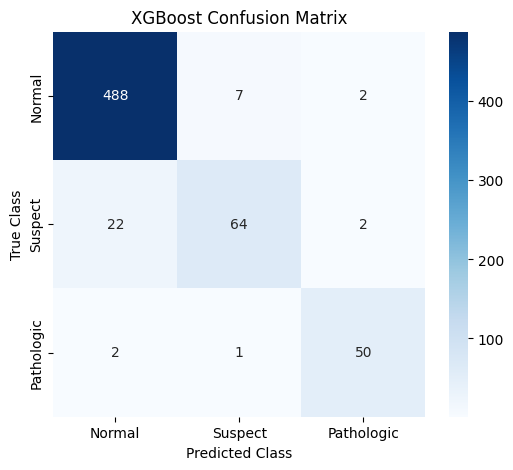

Classification Report:

              precision    recall  f1-score   support

      Normal      0.953     0.982     0.967       497
     Suspect      0.889     0.727     0.800        88
  Pathologic      0.926     0.943     0.935        53

    accuracy                          0.944       638
   macro avg      0.923     0.884     0.901       638
weighted avg      0.942     0.944     0.942       638


Class-Specific Metrics:


,Class,Precision,Recall,F1 Score,Support
0,Normal,0.953125,0.981891,0.967294,497
1,Suspect,0.888889,0.727273,0.800000,88
2,Pathologic,0.925926,0.943396,0.934579,53


Overall Accuracy: 0.944


In [27]:
# 5.1 Confusion Matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    accuracy_score,
    f1_score # Import f1_score explicitly
)

# class labels
class_names = ['Normal', 'Suspect', 'Pathologic']

# predictions
y_pred_xgb = xgb_fitted_model.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('XGBoost Confusion Matrix')
plt.show()

# detailed classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred_xgb, target_names=class_names, digits=3))

# class-specific metrics in dataframe form
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred_xgb)

metrics_df = pd.DataFrame({
    'Class': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'Support': support
})

print("\nClass-Specific Metrics:")
display(metrics_df)

# overall accuracy just for reference
overall_acc = accuracy_score(y_test, y_pred_xgb)
print(f"Overall Accuracy: {overall_acc:.3f}")

**Interpretation:** The XGBoost model performs strongly overall, with high accuracy (94.4%) and excellent performance on the Normal and Pathologic classes. Importantly, it achieves high recall for Pathologic cases (~94%), indicating it is effective at identifying high-risk patients, which is the primary clinical objective. Performance is weaker for the Suspect class (recall ~73%), suggesting some difficulty distinguishing borderline cases. Overall, the model prioritizes detection of critical cases while maintaining strong overall predictive performance.

**b - SHAP for Feature Importance and Effect**

SHAP (SHapley Additive exPlanations) is a method for interpreting machine learning models by assigning each feature a contribution to a specific prediction. It shows both how important each feature is and whether it increases or decreases the predicted outcome. Its purpose is to make complex models transparent and explainable at both the global (overall) and individual prediction level.

In [39]:
# !pip install shap


SHAP Summary for class: Normal


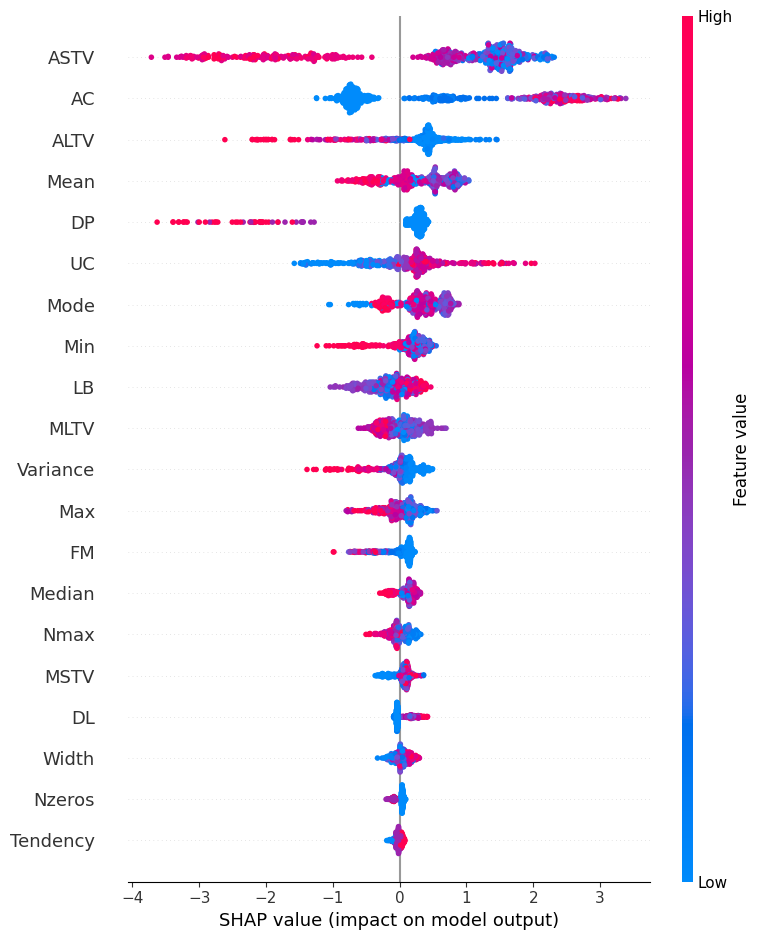


SHAP Summary for class: Suspect


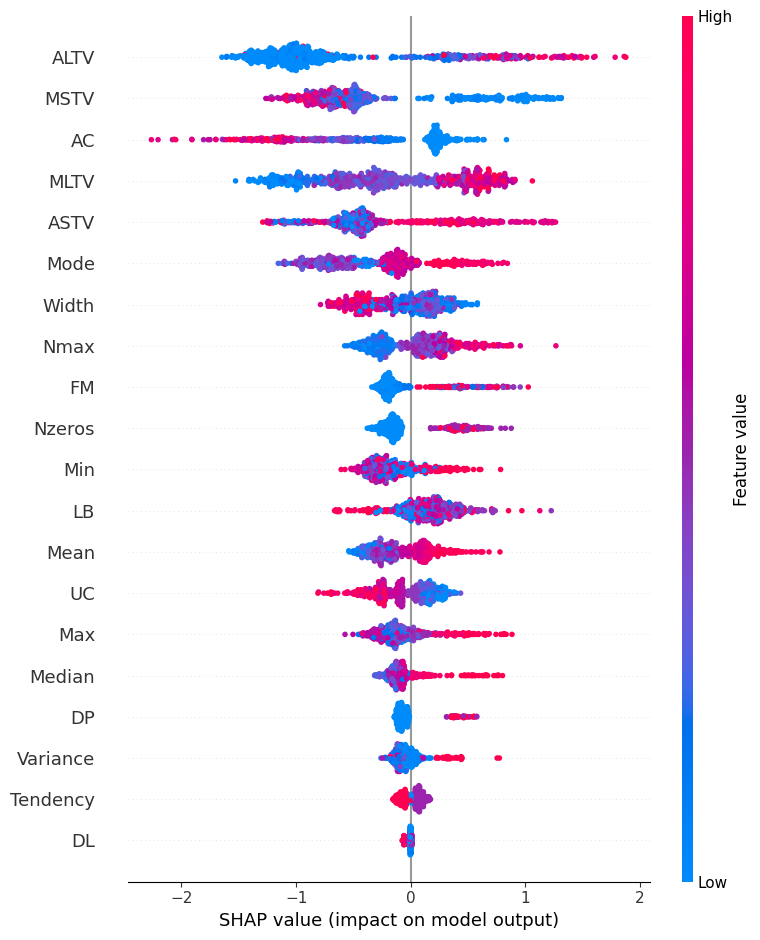


SHAP Summary for class: Pathologic


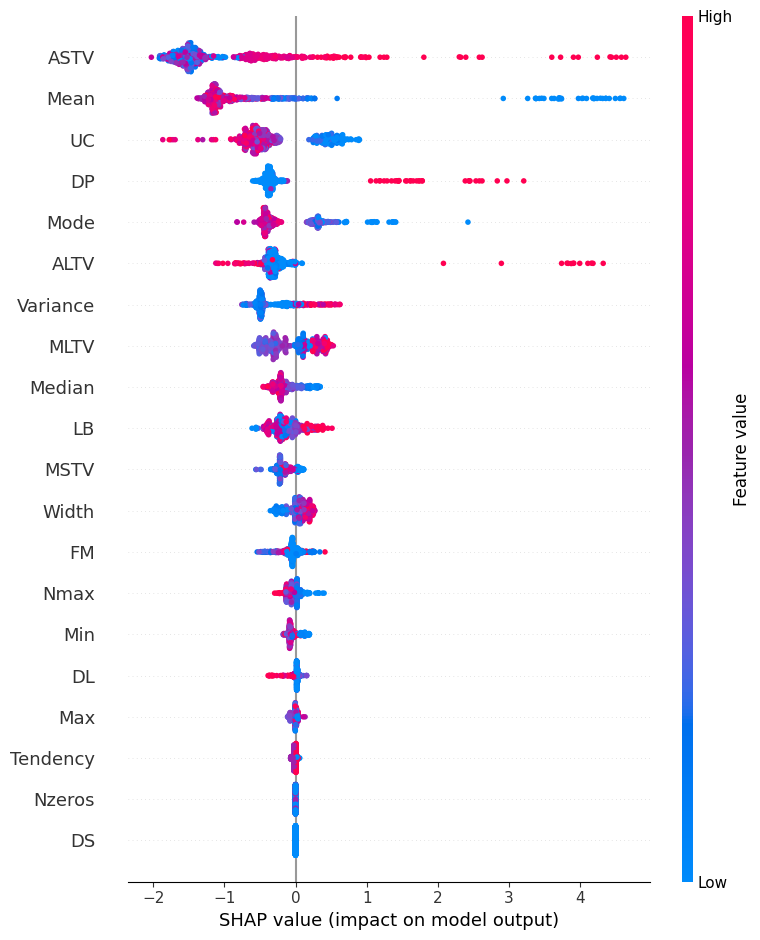

In [40]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# initialize JS only if in notebook
shap.initjs()

# TreeExplainer works well for XGBoost
explainer = shap.TreeExplainer(xgb_fitted_model)
shap_values = explainer.shap_values(X_test)

# For multiclass models, SHAP may return a list of arrays (one per class)
if isinstance(shap_values, list):
    for i, class_name in enumerate(class_names):
        print(f"\nSHAP Summary for class: {class_name}")
        shap.summary_plot(shap_values[i], X_test, show=True)
else:
    # newer shap versions may return shape: (n_samples, n_features, n_classes)
    for i, class_name in enumerate(class_names):
        print(f"\nSHAP Summary for class: {class_name}")
        shap.summary_plot(shap_values[:, :, i], X_test, show=True)

**Interpretation:** Features like ASTV and ALTV likely show increasing SHAP values with higher feature values, meaning higher abnormal variability strongly pushes predictions toward Suspect/Pathologic, which aligns with your clinical interpretation.

SHAP value vs. feature value plots (dependence plots) show how changes in a feature influence the model’s prediction.

- The x-axis is the actual feature value (e.g., ASTV level), and the y-axis is the SHAP value (the feature’s contribution to the prediction).
- When SHAP values increase as the feature increases, it means higher feature values push the model toward a higher-risk class (e.g., Pathologic).
- If SHAP values decrease with higher feature values, then higher values reduce predicted risk.
- Vertical spread at a given x-value indicates interactions with other features (i.e., the same value can have different effects depending on context).


SHAP Feature Importance (Bar) for class: Normal


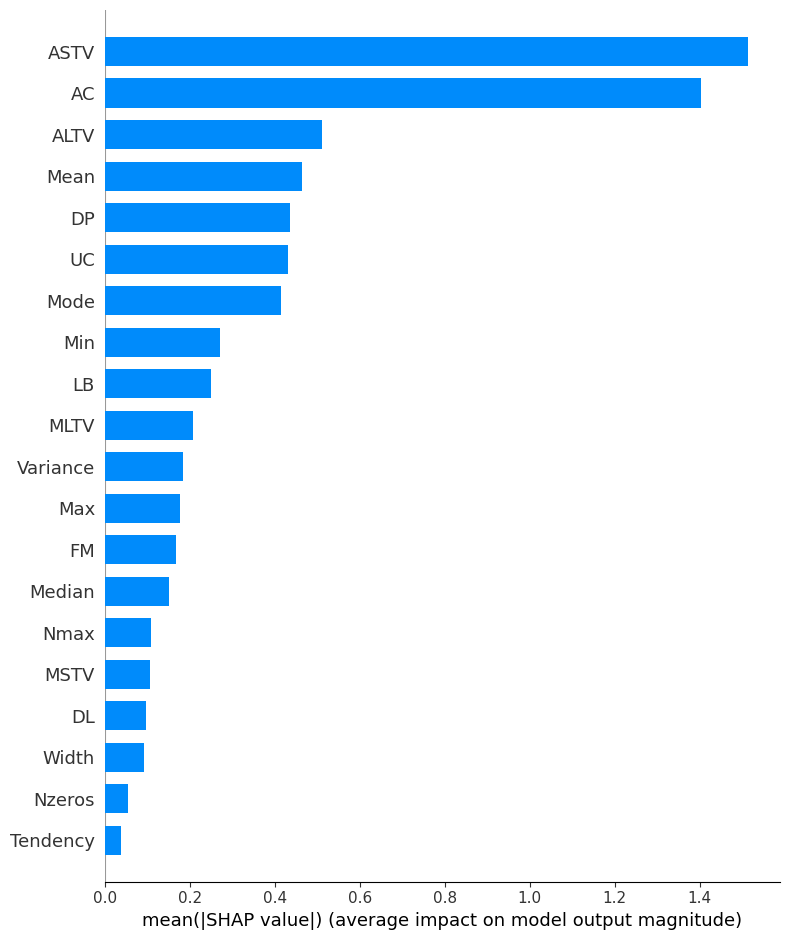


SHAP Feature Importance (Bar) for class: Suspect


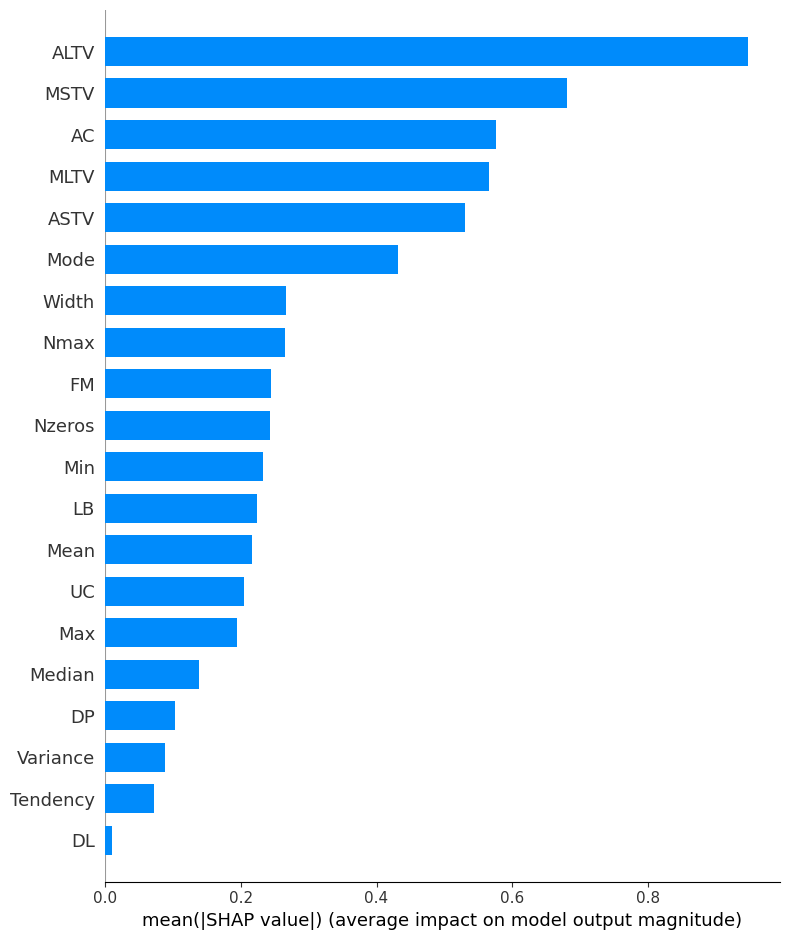


SHAP Feature Importance (Bar) for class: Pathologic


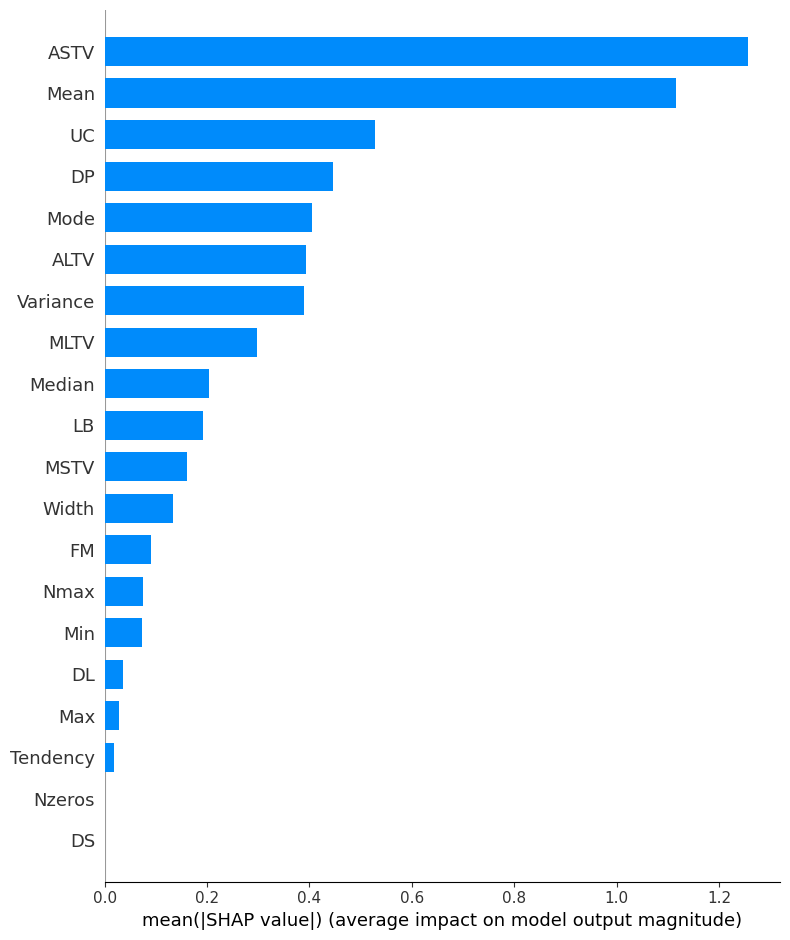

In [41]:
if isinstance(shap_values, list):
    for i, class_name in enumerate(class_names):
        print(f"\nSHAP Feature Importance (Bar) for class: {class_name}")
        shap.summary_plot(shap_values[i], X_test, plot_type='bar', show=True)
else:
    for i, class_name in enumerate(class_names):
        print(f"\nSHAP Feature Importance (Bar) for class: {class_name}")
        shap.summary_plot(shap_values[:, :, i], X_test, plot_type='bar', show=True)

In [42]:
# SHAP-based top features

import numpy as np
import pandas as pd

# Convert SHAP output into a 2D matrix for one-vs-rest interpretation
# We'll average absolute SHAP across classes to get overall importance

if isinstance(shap_values, list):
    # list of (n_samples, n_features) for each class
    abs_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0)   # shape: (n_samples, n_features)
else:
    # array of shape (n_samples, n_features, n_classes)
    abs_shap = np.mean(np.abs(shap_values), axis=2)  # average over classes

mean_abs_shap = abs_shap.mean(axis=0)

shap_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'MeanAbsSHAP': mean_abs_shap
}).sort_values(by='MeanAbsSHAP', ascending=False)

top_10_shap = shap_importance_df.head(10)
display(top_10_shap)

,Feature,MeanAbsSHAP
7,ASTV,1.100076
1,AC,0.659074
9,ALTV,0.616918
17,Mean,0.599224
16,Mode,0.417019
3,UC,0.388306
10,MLTV,0.356787
6,DP,0.328772
8,MSTV,0.315961
0,LB,0.221795


In [43]:
from scipy.stats import spearmanr

direction_results = []

if isinstance(shap_values, list):
    for class_idx, class_name in enumerate(class_names):
        sv = shap_values[class_idx]  # shape: (n_samples, n_features)

        for feature in top_10_shap['Feature']:
            feature_idx = X_test.columns.get_loc(feature)
            corr, _ = spearmanr(X_test.iloc[:, feature_idx], sv[:, feature_idx])

            if corr > 0.1:
                direction = "Higher values increase probability"
            elif corr < -0.1:
                direction = "Lower values increase probability"
            else:
                direction = "Weak / mixed direction"

            direction_results.append({
                'Class': class_name,
                'Feature': feature,
                'Spearman Feature-SHAP Corr': corr,
                'Direction': direction
            })

else:
    for class_idx, class_name in enumerate(class_names):
        sv = shap_values[:, :, class_idx]

        for feature in top_10_shap['Feature']:
            feature_idx = X_test.columns.get_loc(feature)
            corr, _ = spearmanr(X_test.iloc[:, feature_idx], sv[:, feature_idx])

            if corr > 0.1:
                direction = "Higher values increase probability"
            elif corr < -0.1:
                direction = "Lower values increase probability"
            else:
                direction = "Weak / mixed direction"

            direction_results.append({
                'Class': class_name,
                'Feature': feature,
                'Spearman Feature-SHAP Corr': corr,
                'Direction': direction
            })

direction_df = pd.DataFrame(direction_results)
display(direction_df.sort_values(['Class', 'Spearman Feature-SHAP Corr'], ascending=[True, False]))

/tmp/ipykernel_12352/4195996798.py:33: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(X_test.iloc[:, feature_idx], sv[:, feature_idx])


,Class,Feature,Spearman Feature-SHAP Corr,Direction
1,Normal,AC,0.905480,Higher values increase probability
5,Normal,UC,0.830106,Higher values increase probability
8,Normal,MSTV,0.687861,Higher values increase probability
9,Normal,LB,0.558143,Higher values increase probability
7,Normal,DP,-0.461220,Lower values increase probability
4,Normal,Mode,-0.471586,Lower values increase probability
6,Normal,MLTV,-0.484983,Lower values increase probability
2,Normal,ALTV,-0.697552,Lower values increase probability
3,Normal,Mean,-0.722913,Lower values increase probability
0,Normal,ASTV,-0.808038,Lower values increase probability


**Interpretation:** SHAP results showed that variability measures such as ASTV and ALTV, along with baseline heart rate (LB), were the most influential features driving model predictions. Higher values of abnormal variability metrics generally increased the likelihood of Suspect or Pathologic classifications, while normal baseline patterns were associated with lower risk. These findings are consistent with the EDA and align with known clinical interpretations of fetal distress. Overall, SHAP confirms that the model is relying on clinically meaningful signals rather than spurious patterns.

**d- Overfitting Check**

In [57]:
import pandas as pd
from sklearn.metrics import f1_score, recall_score, precision_score

class_names = ['Normal', 'Suspect', 'Pathologic']
pathologic_label_index = 2 # 'Pathologic' is the third class, so its 0-indexed label is 2

# Calculate metrics for the training set for 'Pathologic' class
# We use average='micro' and specify the label to get metrics for a single class
train_f1_pathologic = f1_score(y_train, y_train_pred, labels=[pathologic_label_index], average='micro')
train_recall_pathologic = recall_score(y_train, y_train_pred, labels=[pathologic_label_index], average='micro')
train_precision_pathologic = precision_score(y_train, y_train_pred, labels=[pathologic_label_index], average='micro')

# Calculate metrics for the test set for 'Pathologic' class
test_f1_pathologic = f1_score(y_test, y_test_pred, labels=[pathologic_label_index], average='micro')
test_recall_pathologic = recall_score(y_test, y_test_pred, labels=[pathologic_label_index], average='micro')
test_precision_pathologic = precision_score(y_test, y_test_pred, labels=[pathologic_label_index], average='micro')

# Create a DataFrame to display the results
pathologic_metrics_df = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'F1 Score (Pathologic)': [train_f1_pathologic, test_f1_pathologic],
    'Recall (Pathologic)': [train_recall_pathologic, test_recall_pathologic],
    'Precision (Pathologic)': [train_precision_pathologic, test_precision_pathologic]
})

display(pathologic_metrics_df)

,Dataset,F1 Score (Pathologic),Recall (Pathologic),Precision (Pathologic)
0,Train,1.000000,1.000000,1.000000
1,Test,0.934579,0.943396,0.925926


In [29]:
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score, accuracy_score
import pandas as pd

# predictions (assuming y_train_pred and y_test_pred are defined from xgb_fitted_model)
y_train_pred = xgb_fitted_model.predict(X_train)
y_test_pred = xgb_fitted_model.predict(X_test)

overfit_df = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'Accuracy': [
        accuracy_score(y_train, y_train_pred),
        accuracy_score(y_test, y_test_pred)
    ],
    'F1 Macro': [
        f1_score(y_train, y_train_pred, average='macro'),
        f1_score(y_test, y_test_pred, average='macro')
    ],
    'Recall Macro': [
        recall_score(y_train, y_train_pred, average='macro'),
        recall_score(y_test, y_test_pred, average='macro')
    ],
    'Precision Macro': [
        precision_score(y_train, y_train_pred, average='macro'),
        precision_score(y_test, y_test_pred, average='macro')
    ]
})

display(overfit_df)

,Dataset,Accuracy,F1 Macro,Recall Macro,Precision Macro
0,Train,0.999328,0.999053,0.999712,0.998397
1,Test,0.943574,0.900625,0.884187,0.922647


In [55]:
print("TRAIN Classification Report")
print(classification_report(y_train, y_train_pred, target_names=class_names, digits=3))

print("TEST Classification Report")
print(classification_report(y_test, y_test_pred, target_names=class_names, digits=3))

TRAIN Classification Report
              precision    recall  f1-score   support

      Normal      1.000     0.999     1.000      1158
     Suspect      0.995     1.000     0.998       207
  Pathologic      1.000     1.000     1.000       123

    accuracy                          0.999      1488
   macro avg      0.998     1.000     0.999      1488
weighted avg      0.999     0.999     0.999      1488

TEST Classification Report
              precision    recall  f1-score   support

      Normal      0.953     0.982     0.967       497
     Suspect      0.889     0.727     0.800        88
  Pathologic      0.926     0.943     0.935        53

    accuracy                          0.944       638
   macro avg      0.923     0.884     0.901       638
weighted avg      0.942     0.944     0.942       638



In [30]:
from sklearn.metrics import f1_score # Ensure f1_score is imported

train_f1 = f1_score(y_train, y_train_pred, average='macro')
test_f1 = f1_score(y_test, y_test_pred, average='macro')

gap = train_f1 - test_f1
print(f"Train-Test F1 Gap: {gap:.3f}")

if gap > 0.05:
    print("Possible overfitting: train performance is meaningfully better than test performance.")
else:
    print("No strong evidence of overfitting based on macro F1 gap.")

Train-Test F1 Gap: 0.098
Possible overfitting: train performance is meaningfully better than test performance.


**Interpretation:** The model shows near-perfect performance on the training data but noticeably lower performance on the test set, with a macro F1 drop of about 0.10. This gap indicates moderate overfitting, meaning the model is capturing patterns specific to the training data that do not fully generalize. Despite this, test performance remains strong overall, particularly for the clinically important Pathologic class. This suggests the model is still useful, but could benefit from regularization or tuning to improve generalizability.

## Model Selection and Analysis Summary

---

### 1. Model Selection
All of the models used some sort of automated feature selection in order to reduce the chances of overfitting. We opted to look at 3 different models, SVM, Random Forest, and XGBoost. SVM was the only linear model we looked at since this problem leaned towards tree based models working better. SVM required us to standardize our variables which was done by using `StandardScaler` through a pipeline. SVM was selected because the given values from the dataset are continuous and real numbers. Random forest was selected since there was a mix of integer and continuous values. XGBoost was selected since there seemed to be a non linear relationship between the features and our target value.

---

### 2. Evaluation Metrics
The evaluation metrics we selected were f1-score, precision and recall. F1 score was selected since our original dataset was imbalanced and this would give us a better metric of how our model performed. Precision and recall were used since having either false positives or false negatives could be dangerous for this situation. False positives could lead to unnecesary emergency measures that could result in more complications. False negatives could cause problems with a fetus to be unnoticed possibly leading to the death of that fetus. Overall, the model demonstrates strong performance, particularly in identifying Pathologic cases with high recall, though performance is weaker for the Suspect class, reflecting the challenge of distinguishing borderline cases.

---

### 3. Results
Based on the evaluation metrics we selected, XGBoost performed the best, closely followed by Random Forest and then SVM, confirming that tree based algorithms worked better than linear ones in this case.
